# Import

In [1]:
import os
import gc
import random
from tqdm import tqdm, trange

import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
from scipy import signal

import torch
from torch import tensor
from torch.optim import RMSprop, Adam, NAdam, SGD, Adamax, Adadelta, AdamW, LBFGS, Adagrad
from torch.utils.data import random_split, DataLoader
from torch.nn.functional import normalize
# from torch.utils.data import Dataset, TensorDataset

from datasets import Dataset, DatasetDict, load_from_disk

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import shap
import pickle

from IPython.display import clear_output, Image as IPImage, display
import time

# Config

In [2]:
base = "Exploring-the-Relationship-between-Brain-Hemisphere-States-and-Frequency-Bands-through-Deep-Learning-main/"
INTENSITIES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

DATA_DIR = 'Datasets/'
CP_DIR = 'Checkpoints/'
LOG_DIR = 'Log/'


torch.cuda.empty_cache()
gc.collect()

from torch import nn

class Config:
    EXPERIMENTS = datasets = [
        "Mona Lisa",
        "Necker cube"
        ]
    RHYTHMS = signal_fiq = [
        'alpha',
        'beta',
        'delta',
        'gamma',
        'theta'
        ]
    MODELS = [
        'Big',
        'Small',
        'CNN'
        ]
    OPTIMIZER_LIST = [
        'Adadelta',
        'Adagrad',
        'Adam',
        'Adamax',
        'AdamW',
        'NAdam',
        'RMSprop',
        'SGD'
        ]
    signal_name = signal_fiq
    batch_size = 50
    threshold = 0.001
    seed = 42
    n_folds = 10
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # device = torch.device('cpu')
    epochs = 200
    #epochs = 2
    in_features = 15000
    out_features  = 6400
    activation=nn.ReLU()
    loss_func = nn.CrossEntropyLoss()
    lr_patience = 5
    lr = 1e-5
    save_best_model = False

print(Config.device)

def set_seed(seed = 42):
    torch.initial_seed() % 2**32
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False)
    gseed = torch.Generator().manual_seed(seed)
    # print(worker_seed)
    return gseed

set_seed(Config.seed)

cuda


In [3]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.device(0))
print(torch.cuda.get_device_name(0))


True
1
0
NVIDIA GeForce RTX 4090


# Robiul preparation

In [3]:
class EEG:
    def __init__(self, participant,dataset):

        self.int = {}
        self.delta = {}
        self.theta = {}
        self.alpha = {}
        self.beta = {}
        self.gamma = {}

        #for dataset in datasets:
        if dataset == "Mona Lisa":
                Dname = "/Figs for spectra"
                var1 = "/Backgr_int_"
                var2 = ".dat"
        else:
                Dname = "/Cubes for spectra"
                var1 = "/Backgr_int_"
                var2 = "_type_0.4.dat"

        for intensity in INTENSITIES:
            S = os.path.join(base, "Participant " + str(participant) + Dname + var1 + str(intensity) + var2)
            I = intensity
            self.int[I] = np.loadtxt(S)
            delta_signal = np.empty(self.int[I].shape)
            theta_signal =  np.empty(self.int[I].shape)
            alpha_signal = np.empty(self.int[I].shape)
            beta_signal = np.empty(self.int[I].shape)
            gamma_signal = np.empty(self.int[I].shape)

            for c in range(self.int[I].shape[1]):
                delta_signal[:,c], theta_signal[:,c],alpha_signal[:, c], beta_signal[:, c],gamma_signal[:,c] = self.fir_filtering(I, c)
            self.delta[I] = delta_signal
            self.theta[I] = theta_signal
            self.alpha[I] = alpha_signal
            self.beta[I] = beta_signal 
            self.gamma[I] = gamma_signal

    def fir_filtering(self, I, c):
        filter_delta = signal.firwin(400, [1.0, 4.0], pass_zero=False, fs=250)
        filter_theta = signal.firwin(400, [5.0, 8.0], pass_zero=False, fs=250)
        filter_alpha = signal.firwin(400, [8.0, 12.0], pass_zero=False, fs=250)
        filter_beta = signal.firwin(400, [13.0, 30.0], pass_zero=False, fs=250)
        filter_gamma = signal.firwin(400, [31.0, 45.0], pass_zero=False, fs=250)
        res_delta = signal.convolve(self.int[I][:, c], filter_delta, mode='same')
        res_theta = signal.convolve(self.int[I][:, c], filter_theta, mode='same')
        res_alpha = signal.convolve(self.int[I][:, c], filter_alpha, mode='same')
        res_beta = signal.convolve(self.int[I][:, c], filter_beta, mode='same')
        res_gamma = signal.convolve(self.int[I][:, c], filter_gamma, mode='same')
        
        return res_delta,res_theta, res_alpha,res_beta,res_gamma 

In [4]:
Intencity = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
base = "Exploring-the-Relationship-between-Brain-Hemisphere-States-and-Frequency-Bands-through-Deep-Learning-main/"
file_path = os.path.join(base, "Channels.dat")
df_channels = pd.read_csv(file_path, header=None, sep='.')
channel_names = df_channels.iloc[:, -1:].values.flatten()

def convart_sin_fiq(fiq):
  if fiq == 'delta':
    return 1
  elif fiq == 'theta':
    return 2
  elif fiq == 'alpha':
    return 3
  elif fiq =='beta': 
    return 4
  elif fiq == 'gamma':
    return 5

def createdataframe(user,dataset,signal_fiq):
    global Intencity,channel_names
    tem_signal = []
    eeg_person = EEG(user,dataset)
    for i in Intencity:
        for ch in range(0,31):
            tem = [dataset,ch,channel_names[ch],convart_sin_fiq(signal_fiq),signal_fiq,i,user]
            # tem = [channel_names[ch]]
            S = 'tem_signal.append(np.append(tem, eeg_person.'+signal_fiq+'.get(i)[:,ch][0:15000]))'
            eval(S)
    
           
    tem_dataframe = pd.DataFrame(tem_signal)

    colunm = [] 

    colunm.append("Dataset")
    colunm.append("channel")
    colunm.append("Channel_Name")
    colunm.append("band")
    colunm.append("frequency")
    colunm.append("Intencity")
    colunm.append("participant")

    for col in range(0,15000):
      S = 'Time'+str(col)
      colunm.append(S)    
    
    
    
    tem_dataframe.columns  = colunm 
    return tem_dataframe

# Dataset

In [5]:
df = DataFrame()

for experiment in Config.EXPERIMENTS:
    for rhythm in Config.RHYTHMS:
        participants = trange(1, 11, leave=True)
        for user in participants:
            df = pd.concat([df, createdataframe(user, experiment, rhythm)], ignore_index=True)
            participants.set_postfix(rhythm=rhythm, user=user, counts=len(df),  experiment=experiment, refresh=True)

100%|█| 10/10 [00:32<00:00,  3.28s/it, counts=3100, experiment=Mona Lisa, rhythm
100%|█| 10/10 [00:39<00:00,  3.96s/it, counts=6200, experiment=Mona Lisa, rhythm
100%|█| 10/10 [00:47<00:00,  4.77s/it, counts=9300, experiment=Mona Lisa, rhythm
100%|█| 10/10 [00:57<00:00,  5.79s/it, counts=12400, experiment=Mona Lisa, rhyth
100%|█| 10/10 [01:06<00:00,  6.65s/it, counts=15500, experiment=Mona Lisa, rhyth
100%|█| 10/10 [01:15<00:00,  7.55s/it, counts=18600, experiment=Necker cube, rhy
100%|█| 10/10 [01:24<00:00,  8.45s/it, counts=21700, experiment=Necker cube, rhy
100%|█| 10/10 [01:33<00:00,  9.33s/it, counts=24800, experiment=Necker cube, rhy
100%|█| 10/10 [01:47<00:00, 10.78s/it, counts=27900, experiment=Necker cube, rhy
100%|█| 10/10 [01:51<00:00, 11.15s/it, counts=31000, experiment=Necker cube, rhy


In [6]:
df

,Dataset,channel,Channel_Name,band,frequency,Intencity,participant,Time0,Time1,Time2,...,Time14990,Time14991,Time14992,Time14993,Time14994,Time14995,Time14996,Time14997,Time14998,Time14999
0,Mona Lisa,0,O2-A2,3,alpha,0.1,1,-3.7877484676085507,-18.4037880568239,-31.726911379759112,...,-18.91265003606081,-21.11098576948976,-22.139076996590173,-21.838392961197147,-20.12747732240493,-17.020426535507227,-12.629057427081623,-7.153919067630163,-0.8819641114161927,5.823794977252651
1,Mona Lisa,1,O1-A1,3,alpha,0.1,1,-7.968681354835845,-8.840463565797092,-9.143071285582437,...,-25.328021373027568,-24.306133658255284,-21.576791341405556,-17.27470845429491,-11.651353312626226,-5.068360933975659,2.0344586327692324,9.175119081980128,15.854464009792547,21.587947836018422
2,Mona Lisa,2,P4-A2,3,alpha,0.1,1,-13.373959023272686,-11.517050415805972,-8.740575990131848,...,-22.218528466530856,-23.959918766346572,-24.07050886219999,-22.541134224679844,-19.479654219201514,-15.10329722413013,-9.722216730846245,-3.717187175826689,2.48814240193232,8.459409395160073
3,Mona Lisa,3,P3-A1,3,alpha,0.1,1,-6.756083132735056,-6.946923495303239,-6.669265523565157,...,-37.05168777620561,-38.00202122586408,-36.519980673671185,-32.607470453482264,-26.43414483021141,-18.33143251953191,-8.774428652511975,1.6494019513770515,12.27726666440899,22.41351732110965
4,Mona Lisa,4,C4-A2,3,alpha,0.1,1,-3.276661483237142,-8.660899524772816,-13.31567807297543,...,-6.013956211747249,-5.0920186212204985,-3.929964006330922,-2.645906214314347,-1.3585303122483667,-0.17540624288828377,0.8131139575224788,1.5413807435493134,1.9744935836624107,2.1090197820147507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30995,Necker cube,26,TP7-A1,2,theta,1,10,-1.2033169086332713,-8.917665522796096,-16.384544736424903,...,-15.160986260779456,-17.43429221808814,-19.32534165434078,-20.781407457983043,-21.760886417505162,-22.236968177048933,-22.199460640479426,-21.652988188689374,-20.616067697629166,-19.12201239592823
30996,Necker cube,27,CP3-A1,2,theta,1,10,13.011341633195856,6.409551203884137,-0.32399945771915917,...,-20.302737627617784,-26.19003229384053,-31.40718806113646,-35.80694469215708,-39.265896944882535,-41.69072431637579,-43.021285734126735,-43.231056458927775,-42.326663790428995,-40.34840000354953
30997,Necker cube,28,Cpz-A1,2,theta,1,10,19.268161081846017,11.741938784955572,3.94068533379655,...,-17.672843575269706,-23.210318635939622,-28.250487846200205,-32.639049784861,-36.23932423404942,-38.939599398823674,-40.65685179559212,-41.337027767005736,-40.95611205341861,-39.522983252514926
30998,Necker cube,29,CP4-A2,2,theta,1,10,16.5270341215045,27.75337946057632,38.244783344956616,...,10.500251657435188,6.102757216483038,1.451781497355989,-3.2973818963341444,-7.983747840379518,-12.452134012415861,-16.55614035348089,-20.159761486725323,-23.143412934305054,-25.40888847137986


In [10]:
df.iloc[:,7:].duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
30995    False
30996    False
30997    False
30998    False
30999    False
Length: 31000, dtype: bool

In [11]:
dataset = DatasetDict()
splits = df['frequency'].unique()

for split in tqdm(splits):
    # dataset = DatasetDict(
    #     {split: Dataset.from_pandas(df[df['frequency'] == split])}
    # )
    dataset[split] = Dataset.from_pandas(df[df['frequency'] == split], split=split)

print(dataset)

100%|████████████████████████████████████████████| 5/5 [09:26<00:00, 113.23s/it]

DatasetDict({
    alpha: Dataset({
        features: ['Dataset', 'channel', 'Channel_Name', 'band', 'frequency', 'Intencity', 'participant', 'Time0', 'Time1', 'Time2', 'Time3', 'Time4', 'Time5', 'Time6', 'Time7', 'Time8', 'Time9', 'Time10', 'Time11', 'Time12', 'Time13', 'Time14', 'Time15', 'Time16', 'Time17', 'Time18', 'Time19', 'Time20', 'Time21', 'Time22', 'Time23', 'Time24', 'Time25', 'Time26', 'Time27', 'Time28', 'Time29', 'Time30', 'Time31', 'Time32', 'Time33', 'Time34', 'Time35', 'Time36', 'Time37', 'Time38', 'Time39', 'Time40', 'Time41', 'Time42', 'Time43', 'Time44', 'Time45', 'Time46', 'Time47', 'Time48', 'Time49', 'Time50', 'Time51', 'Time52', 'Time53', 'Time54', 'Time55', 'Time56', 'Time57', 'Time58', 'Time59', 'Time60', 'Time61', 'Time62', 'Time63', 'Time64', 'Time65', 'Time66', 'Time67', 'Time68', 'Time69', 'Time70', 'Time71', 'Time72', 'Time73', 'Time74', 'Time75', 'Time76', 'Time77', 'Time78', 'Time79', 'Time80', 'Time81', 'Time82', 'Time83', 'Time84', 'Time85', 'Time86',

In [12]:
dataset.save_to_disk('test')

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

In [13]:
# df.to_csv('dataframe.csv')
# df = pd.read_csv('dataframe.csv', index_col=0)

In [14]:
# dataset = Dataset.from_pandas(df)
dataset.save_to_disk(DATA_DIR)

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

Saving the dataset (0/5 shards):   0%|          | 0/6200 [00:00<?, ? examples/s]

## Loading

In [15]:
dataset = load_from_disk(DATA_DIR)

In [16]:
df = dataset['beta'].to_pandas()
tdf = df.iloc[:, 7:]
tdf.drop(columns='__index_level_0__', inplace=True)

In [17]:
dataset

DatasetDict({
    alpha: Dataset({
        features: ['Dataset', 'channel', 'Channel_Name', 'band', 'frequency', 'Intencity', 'participant', 'Time0', 'Time1', 'Time2', 'Time3', 'Time4', 'Time5', 'Time6', 'Time7', 'Time8', 'Time9', 'Time10', 'Time11', 'Time12', 'Time13', 'Time14', 'Time15', 'Time16', 'Time17', 'Time18', 'Time19', 'Time20', 'Time21', 'Time22', 'Time23', 'Time24', 'Time25', 'Time26', 'Time27', 'Time28', 'Time29', 'Time30', 'Time31', 'Time32', 'Time33', 'Time34', 'Time35', 'Time36', 'Time37', 'Time38', 'Time39', 'Time40', 'Time41', 'Time42', 'Time43', 'Time44', 'Time45', 'Time46', 'Time47', 'Time48', 'Time49', 'Time50', 'Time51', 'Time52', 'Time53', 'Time54', 'Time55', 'Time56', 'Time57', 'Time58', 'Time59', 'Time60', 'Time61', 'Time62', 'Time63', 'Time64', 'Time65', 'Time66', 'Time67', 'Time68', 'Time69', 'Time70', 'Time71', 'Time72', 'Time73', 'Time74', 'Time75', 'Time76', 'Time77', 'Time78', 'Time79', 'Time80', 'Time81', 'Time82', 'Time83', 'Time84', 'Time85', 'Time86',

## Spectrogram

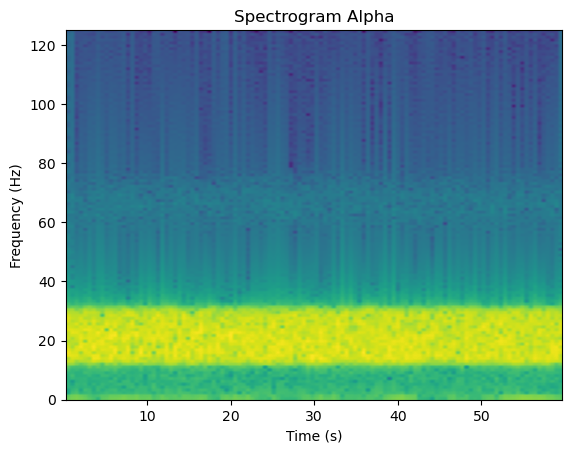

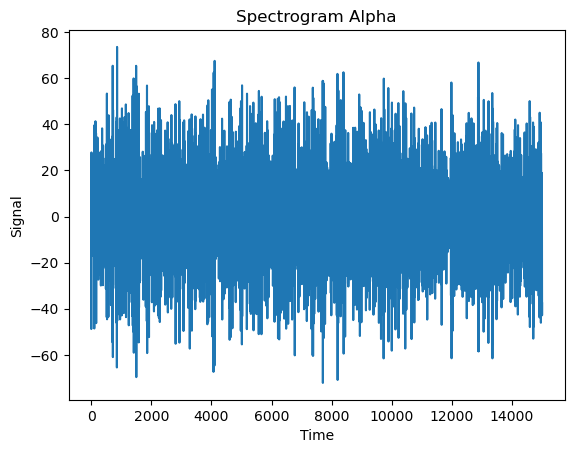

In [20]:
data = tdf.iloc[5].values
data = data.astype(float)
#data.tolist()


#fig, (ax1) = plt.subplots(nrows=1, sharex=True)

plt.specgram(data.T, Fs=250, cmap="viridis")
plt.title('Spectrogram Alpha')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

plt.title('Spectrogram Alpha')
plt.xlabel("Time")
plt.ylabel("Signal")
plt.plot(data)

## Split

In [21]:
df = dataset['beta'].to_pandas()
df.drop(columns='__index_level_0__', inplace=True)
tdf = df.iloc[:]['Channel_Name']
_tdf = df.iloc[:, 7:]
# tdf.drop(columns='__index_level_0__', inplace=True)

In [22]:
temp = pd.concat([tdf,_tdf], axis=1)

In [23]:
_tdf.reset_index(drop=True, inplace=True)

In [24]:
temp.set_index('Channel_Name')

,Time0,Time1,Time2,Time3,Time4,Time5,Time6,Time7,Time8,Time9,...,Time14990,Time14991,Time14992,Time14993,Time14994,Time14995,Time14996,Time14997,Time14998,Time14999
Channel_Name,,,,,,,,,,,,,,,,,,,,,
O2-A2,24.36388999243425,-30.897185875590992,-78.75316433767904,-105.38935045444425,-103.69468462073522,-75.42832510842197,-30.19667002558433,18.209751060085544,56.572246266131785,76.27106707668165,...,-36.019788596574486,-22.42537513403454,-3.7533300764159456,13.395360224367517,23.843026700989533,25.3922761997362,19.09846191018979,8.331542898163132,-2.8289924390526515,-11.124044602632699
O1-A1,-11.464370825867821,-11.992797188074777,-9.513141809044777,-5.320424422626084,-0.9582538951238342,2.5275097514924108,4.948425144132477,6.774732815824461,8.533636161609683,10.207162997067899,...,-15.14727481603865,-6.572393757053922,5.609173748316239,20.170590216617565,33.629848908952795,41.00640774280332,37.85927613899937,22.68188631763308,-1.60652034971897,-28.02054715806085
P4-A2,3.2754118130900354,18.37741992992648,28.666396598245264,31.27600497761251,26.008260156028012,15.33202278471552,3.318191615331922,-6.047260057522729,-10.453965909583417,-10.077022905330047,...,10.584201732508433,16.61067014827924,20.253447157002398,20.376752032466598,16.45333887555976,8.594942534964265,-2.3995923159426784,-14.982774093452074,-26.889960467591123,-35.40738947887934
P3-A1,3.1796950438408436,20.99708314438842,33.301327435977434,36.25661029934813,29.21948688578684,14.965231543349528,-1.4206731396617513,-14.533914103382367,-20.696364432203154,-19.20976323763669,...,1.36677851947773,16.47913461574894,27.91436518201086,32.040875754274886,27.24437787150181,14.361563557544581,-3.561880646326309,-22.100249431172827,-36.62260399751691,-43.48499277788949
C4-A2,18.304522360532044,10.35023244115196,1.338145494791151,-6.469090873174041,-11.404978115541436,-12.801253251966774,-11.052158704694198,-7.374586999068512,-3.374090203218338,-0.5523796597508932,...,29.50011983874952,31.49589395892546,24.65661662998302,9.919940825049068,-9.126565873148289,-27.456984224089293,-40.30119669413911,-44.64427392288371,-39.97669267489675,-28.085919675839467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TP7-A1,2.1296883073108255,-33.562262617861805,-60.25737412134717,-71.74787167732487,-66.61392254767415,-48.04575415356502,-22.161927165417897,4.330649312431467,26.14751694713717,40.428991233546,...,7.462059568981935,8.46826634903288,9.417394659038074,10.31518162323249,10.725782476215834,9.96655616914309,7.462854137696404,3.080105726464069,-2.721528881186167,-8.964309955593514
CP3-A1,-13.124200069247523,-38.165695298438514,-51.95849494694027,-51.31356844947409,-38.004174542571874,-17.60071218578444,3.046220205271526,18.49336032340351,26.40145747852855,27.630980033730772,...,17.043006817245914,11.839232793691462,6.78678470773675,3.1120802721330705,0.9094898245219483,-0.6074823703753225,-2.4593665852492705,-5.227480377796084,-8.696379954223971,-11.953015081912213
Cpz-A1,-18.16484472887774,-52.471322114291866,-72.14176185833185,-71.94660468893643,-53.41140196130679,-23.787135333405924,7.088143057900275,30.610174029333738,42.278726855960315,42.52052997740207,...,8.35017355269111,12.420965277003816,15.428227028622722,15.457536040785975,11.136292990435734,2.4730682794651173,-8.759723073992326,-19.383875436520633,-25.869961264864912,-25.694959939934705


In [25]:
ds = Dataset.from_pandas(temp)

In [26]:
t1 = ds.remove_columns("Channel_Name")
t1

Dataset({
    features: ['Time0', 'Time1', 'Time2', 'Time3', 'Time4', 'Time5', 'Time6', 'Time7', 'Time8', 'Time9', 'Time10', 'Time11', 'Time12', 'Time13', 'Time14', 'Time15', 'Time16', 'Time17', 'Time18', 'Time19', 'Time20', 'Time21', 'Time22', 'Time23', 'Time24', 'Time25', 'Time26', 'Time27', 'Time28', 'Time29', 'Time30', 'Time31', 'Time32', 'Time33', 'Time34', 'Time35', 'Time36', 'Time37', 'Time38', 'Time39', 'Time40', 'Time41', 'Time42', 'Time43', 'Time44', 'Time45', 'Time46', 'Time47', 'Time48', 'Time49', 'Time50', 'Time51', 'Time52', 'Time53', 'Time54', 'Time55', 'Time56', 'Time57', 'Time58', 'Time59', 'Time60', 'Time61', 'Time62', 'Time63', 'Time64', 'Time65', 'Time66', 'Time67', 'Time68', 'Time69', 'Time70', 'Time71', 'Time72', 'Time73', 'Time74', 'Time75', 'Time76', 'Time77', 'Time78', 'Time79', 'Time80', 'Time81', 'Time82', 'Time83', 'Time84', 'Time85', 'Time86', 'Time87', 'Time88', 'Time89', 'Time90', 'Time91', 'Time92', 'Time93', 'Time94', 'Time95', 'Time96', 'Time97', 'Time

In [28]:
#torch.tensor(t1, dtype=torch.float64, device='cuda')

## Load

In [56]:
DATASET = load_from_disk(dataset_path=DATA_DIR)

In [57]:
from sklearn.calibration import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from datasets import load_from_disk, Dataset
# import datasets

from torch.utils.data.dataset import Dataset


class CustomDataset(Dataset):
    def __init__(self, experiment: str, signal: str, dataset = DATASET, normalize = None, batch_size=Config.batch_size):

        super(CustomDataset, self).__init__()
        self.batch_size = batch_size

        # self.dataset = dataset['alpha'][5]

        # self.dataframe = pd.DataFrame.from_dict(self.dataset)
        # print(self.dataframe)


        self.dataset = dataset[signal].remove_columns('__index_level_0__')
        self.dataframe = self.dataset.to_pandas()
        self.dataframe = self.dataframe[self.dataframe['Dataset'] == experiment]
        self.index_list = self.dataframe.index.to_list()
        self.normalize = normalize
        # self.tensors = self.get_tensors()

        self.X_df = self.X_df()
        self.y_df = self.y_df()

        self.generator_seed = set_seed(Config.seed)

        self.train, self.val, self.test = self.train_val_test()

        self.train_dataloader = self.train_dataloader()
        self.val_dataloader = self.val_dataloader()
        self.test_dataloader = self.test_dataloader()

    def __len__(self):
        return len(self.dataframe)

    # def __getitem__(self, idx):
    #     return self.tensor[idx]+1
    
    def shape(self):
        return self.tensor.shape
    
    def size(self) -> int:
        return super().__sizeof__(self.__len__(), *self.__getitem__(0)[0].shape)

    # def get_tensors(self):
    #     label = self.dataframe['Channel_Name'].map(lambda x: np.int8(0) if 'A1' in x else np.int8(1))
    #     t_label =  torch.tensor(label, dtype=torch.float)
    #     _time = self.dataframe.iloc[:, 7:].to_numpy()
    #     t_time = torch.tensor(_time, dtype=torch.float)
    #     if self.normalize:
    #         t_time = normalize(t_time, p=2, dim = 0).float()   
    #     return TensorDataset(t_label, t_time)
    
    def X_df(self):
        return self.dataframe.iloc[:, 7:]
    
    def y_df(self):

        # Ваш список классов
        classes = [' O2-A2', ' O1-A1', ' P4-A2', ' P3-A1', ' C4-A2', ' C3-A1',
                ' F4-A2', ' F3-A1', ' Fp2-A2', ' Fp1-A1', ' T6-A2', ' T5-A1',
                ' T4-A2', ' T3-A1', ' F8-A2', ' F7-A1', ' Oz-A2', ' Pz-A1',
                ' Cz-A2', ' Fz-A1', ' Fpz-A2', ' FT7-A1', ' FC3-A1', ' Fcz-A1',
                ' FC4-A2', ' FT8-A2', ' TP7-A1', ' CP3-A1', ' Cpz-A1', ' CP4-A2',
                ' TP8-A2']

        # Создаем DataFrame из списка классов
        # df = pd.DataFrame(classes, columns=['Class'])

        # Создаем объект LabelEncoder
        label_encoder = LabelEncoder()

        # Применяем LabelEncoder к столбцу 'Class'
        # self.dataframe['Class_encoded'] = label_encoder.fit_transform(self.dataframe['Channel_Name'])

        label = self.dataframe['Channel_Name'].map(lambda x: np.int8(0) if 'A1' in x else np.int8(1))

        # label = self.dataframe['Class_encoded']
        return label
    
    def train_val_test(self):
        self.dataframe['Stratify'] = self.dataframe['Channel_Name'].astype(str) + '_' + self.dataframe['Intencity'].astype(str)

        train_x, val_x, train_y, val_y, train_idx, val_idx = train_test_split(self.X_df, self.y_df, self.index_list,
                                            test_size=0.2,
                                            shuffle=True,
                                            stratify=self.dataframe['Stratify'],
                                            ) 
        val_x, test_x, val_y, test_y, val_idx, test_idx = train_test_split(val_x, val_y, val_idx,
                                            test_size=0.5,
                                            shuffle=True,
                                            stratify=val_y,
                                            )
        

        # x = normalize(torch.tensor(test_x.values, dtype=torch.float), p=2, dim = 0) 
        # print(x[0][0].item())
        # train_x.reset_index(drop=True, inplace=True)
        # val_x.reset_index(drop=True, inplace=True)
        # test_x.reset_index(drop=True, inplace=True)
        # train_y.reset_index(drop=True, inplace=True)
        # val_y.reset_index(drop=True, inplace=True)
        # test_y.reset_index(drop=True, inplace=True)

        # x_train = normalize(torch.tensor(train_x.values, dtype=torch.float), p=1, dim = 1)
        # x_val = normalize(torch.tensor(val_x.values, dtype=torch.float), p=1, dim = 1)
        # x_test = normalize(torch.tensor(test_x.values, dtype=torch.float), p=1, dim = 1)

        train_x = torch.tensor(train_x.values.astype(float), dtype=torch.float)
        val_x = torch.tensor(val_x.values.astype(float), dtype=torch.float)
        test_x = torch.tensor(test_x.values.astype(float), dtype=torch.float)

        train_idx = torch.tensor(train_idx, dtype=torch.int)
        val_idx = torch.tensor(val_idx, dtype=torch.int)
        test_idx = torch.tensor(test_idx, dtype=torch.int)


        train_x_y = TensorDataset(train_x, torch.tensor(train_y.values, dtype=torch.long), train_idx)
        val_x_y = TensorDataset(val_x, torch.tensor(val_y.values, dtype=torch.long), val_idx)
        test_x_y = TensorDataset(test_x, torch.tensor(test_y.values, dtype=torch.long), test_idx)

        return train_x_y, val_x_y, test_x_y
    
    def train_dataloader(self):
        train_dataloader = DataLoader(self.train, batch_size=self.batch_size, shuffle=True, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return train_dataloader
    
    def val_dataloader(self):
        val_dataloader = DataLoader(self.val, batch_size=self.batch_size, shuffle=False, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return val_dataloader
    
    def test_dataloader(self):
        test_dataloader = DataLoader(self.test, batch_size=self.batch_size, shuffle=False, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return test_dataloader

# Model

In [58]:
import os
import random
import numpy as np
import torch.nn as nn

class RobiulModel(nn.Module):

    def __init__(self,
                model_name = 'Small',
                experiment = Config.EXPERIMENTS[0],
                rhythm = Config.RHYTHMS[0],
                optimizer = Config.OPTIMIZER_LIST[0],
                in_features = Config.in_features,
                out_features = Config.out_features,
                lr = Config.lr,
                batch_size = Config.batch_size,
                shap_mode = False,
                ):
        
        super(RobiulModel, self).__init__()

        gc.collect()
        if Config.device == 'cuda': torch.cuda.empty_cache()
        self.shap_mode = shap_mode
        self.dataset =  CustomDataset(experiment=experiment, signal=rhythm, batch_size=batch_size)
        self.config(in_features, out_features)
        self.activation = Config.activation
        self.model_name = model_name
        self.experiment = experiment
        self.rhythm = rhythm
        self.optimizer = optimizer
        self.lr = lr
        self.batch_size = batch_size
        self.best_epoch = 0
        self.best_val_acc = 0
        self.best_test_acc = 0
        self.threshold = 0.5
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.epochs = Config.epochs
        self.lr_hist = []
        self.best_loss = None
        self.count = 0
        self.test_loss = []
        self.test_acc = []

        self.X_cr = []
        self.roc_lr_probs = []

        self.sm=nn.Softmax(dim=1)
    

        if model_name == 'Big':
            self.lr = 1e-2
            self.linear_stack = nn.Sequential(
                nn.Linear(self.in_features, self.out_features, bias=False),
                self.activation,
                nn.BatchNorm1d(self.out_features),
                nn.Linear(self.out_features, 1000, bias=False),
                self.activation,
                nn.BatchNorm1d(1000),
                nn.Linear(1000, 500, bias=False),
                self.activation,
                nn.BatchNorm1d(500),
                nn.Linear(500, 200, bias=False),
                self.activation,
                nn.BatchNorm1d(200),
                nn.Linear(200, 100, bias=False),
                self.activation,
                nn.BatchNorm1d(100),
                nn.Linear(100, 50, bias=False),
                self.activation,
                nn.BatchNorm1d(50),
                nn.Linear(50, 25, bias=False),
                self.activation,
                nn.BatchNorm1d(25),
                nn.Linear(25, 15, bias=False),
                self.activation,
                nn.BatchNorm1d(15),
                nn.Linear(15, 10, bias=False),
                self.activation,
                nn.BatchNorm1d(10),
                nn.Linear(10, 1, bias=False),
                # self.activation,
                # nn.BatchNorm1d(1),
                nn.Sigmoid(),
            )
        elif model_name == 'Small':
            self.lr = 1e-5
            self.linear_stack = nn.Sequential(
                nn.Linear(self.in_features, self.out_features, bias=False),
                self.activation,
                nn.BatchNorm1d(self.out_features),
                nn.Linear(self.out_features, 10, bias=False),
                self.activation,
                nn.BatchNorm1d(10),
                nn.Linear(10, 1, bias=False),
                nn.Sigmoid(),
                
            )            
        elif model_name == 'CNN':
            self.lr = 1e-3
            self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 64, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            )

            self.cnn_linear = nn.Sequential(
                nn.Linear(240000, self.batch_size),
                nn.LeakyReLU(inplace=True),
                nn.Linear(self.batch_size, 2),
            )

        self = self.to(Config.device)
        self.settings()        
        self.metrics_dir = f"{LOG_DIR}{self.model_name}_{self.experiment.replace(' ', '_')}_{self.rhythm}_{self.optimizer.__class__.__name__}/"        

    
    def forward(self, x):
        if self.model_name == 'CNN':
            x = x.unsqueeze(1)
            x = self.cnn(x)
            x = x.view(x.size(0), -1)
            x = self.cnn_linear(x)
            return x
        else:
            if self.shap_mode:
                x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device(Config.device))
            logits = self.linear_stack(x)
            logits = logits.squeeze()
            return logits
    
    def config(self,
        in_features = Config.in_features,
        out_features = Config.out_features):
        self.in_features = in_features
        self.out_features = out_features
    
    def settings(self):
        self.loss_func = Config.loss_func
        
        if self.optimizer == 'NAdam':
            self.optimizer = NAdam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'SGD':
            self.optimizer = SGD(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adam':
            self.optimizer = Adam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'AdamW':
            self.optimizer = Adam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'RMSprop':
            self.optimizer = RMSprop(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adamax':
            self.optimizer = Adamax(self.parameters(), lr=self.lr)  
        elif self.optimizer == 'LBFGS':
            self.optimizer = LBFGS(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adadelta':
            self.optimizer = Adadelta(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adagrad':
            self.optimizer = Adagrad(self.parameters(), lr=self.lr)            

        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=self.optimizer,
                                                                mode='min',
                                                                patience=Config.lr_patience,
                                                                # threshold=Config.threshold,
                                                                threshold_mode='rel',
                                                                # cooldown=0,
                                                                min_lr=0,
                                                                # eps=1e-8,
                                                                )
        
    def fit(self):   
        self.start_time = time.time()
        
        for epoch in range(self.epochs):
            train_loop = tqdm(self.dataset.train_dataloader, leave=False)
            train_loss = 0.0
            correct = 0
            self.train()
            for batch in train_loop:
                self.optimizer.zero_grad()
                X = batch[0].to(Config.device)
                targets = batch[1].to(Config.device)
                pred = self(X)

                if self.model_name == 'CNN':
                    # print(targets.shape,'\n', pred.shape)
                    # print(targets, '\n', pred)
                    # targets = targets.long()
                    # loss = self.loss_func(pred, targets)
                    loss = self.loss_func(pred, targets.to(torch.long))
                    smp=self.sm(pred)
                 
                    pred = pred.argmax(dim=1)
                    # print(targets.shape,'\n', pred.shape)                    
                    predicted_classes = (smp[:,1] >= self.threshold).to(torch.int)                
                else:
                    targets = targets.to(torch.float) 
                    loss = self.loss_func(pred, targets)    
                    predicted_classes = (pred >= self.threshold).to(torch.int)

                loss.backward()
                self.optimizer.step()

                # running_train_loss.append(loss)
                train_loss += loss.item() * targets.size(0)  # Суммируем потери, умноженные на размер батча

                mean_train_loss = train_loss / len(self.dataset.train_dataloader.sampler)

                # print(predicted_classes.shape, targets.shape)

                # true_answers += sum(predicted_classes == targets)

                train_loop.set_description(f'Epoch: [{epoch+1}/{self.epochs}]')
               
                correct += torch.eq(predicted_classes, targets).sum().item()

                running_train_acc = correct / len(self.dataset.train)

            self.train_loss.append(mean_train_loss)
            self.train_acc.append(running_train_acc)

            self.eval()
            val_loss = 0.0
            with torch.no_grad():

                # running_val_loss = []
                correct = 0

                for batch in self.dataset.val_dataloader:

                    X = batch[0].to(Config.device)
                    targets = batch[1].to(Config.device)

                    pred = self(X)

                    # print(X.shape, pred.shape, targets.shape)

                    if self.model_name == 'CNN':
                        loss = self.loss_func(pred, targets.to(torch.long))
                        smp=self.sm(pred)
                        pred = pred.argmax(dim=1)

                        #print(smp)
                        #print(pred)
                        
                        predicted_classes = (smp[:,1] >= self.threshold).to(torch.int)  
                    else:
                        # print(X.shape, pred.shape, targets.shape)
                        # print(X, pred, targets)
                        # pred = torch.round(pred)
                        # pred = pred.argmax(dim=0)
                        loss = self.loss_func(pred.to(torch.float), targets.to(torch.float))
                        predicted_classes = (pred >= self.threshold).to(torch.int)

                    # running_val_loss.append(loss.item())
                    # mean_val_loss = sum(running_val_loss) / len(running_val_loss)

                    val_loss += loss.item() * targets.size(0)
                    val_size = len(self.dataset.val_dataloader.sampler)
                    mean_val_loss = val_loss / val_size 

                    # true_answers += sum(predicted_classes == targets)
                    # max_values, _ = torch.max(tensor, dim=1, keepdim=True)

                    # print(pred.shape, targets.shape)
                    # print(X.shape, pred.shape, targets.shape)
                    # print(X, pred, targets)

                    correct += torch.eq(predicted_classes, targets).sum().item()
            # break
            running_val_acc = correct / len(self.dataset.val) # true_answers / len(train_dataset.val)

            self.val_loss.append(mean_val_loss)
            self.val_acc.append(running_val_acc)

            self.lr_scheduler.step(mean_val_loss)
            lr = self.lr_scheduler.get_last_lr()[0]
            self.lr_hist.append(lr)

            print(f"Epoch: [{epoch+1}/{self.epochs}] | train_loss = [{mean_train_loss:.4f}] : train_acc = [{running_train_acc:.4f}] : val_loss = [{mean_val_loss:.4f}] : val_acc = [{running_val_acc:.4f}] : lr = [{lr}]")

            if self.best_loss is None:
                self.best_loss = mean_val_loss
            
            if self.best_loss > mean_val_loss:

                # Save best model
                print(f'Find best loss=[{self.best_loss}], model saved on {epoch+1} epoch')                
                if Config.save_best_model:
                    if not os.path.exists(self.metrics_dir): os.makedirs(self.metrics_dir, exist_ok=True)                       
                    torch.save(self.state_dict(), f'{self.metrics_dir}best_model.pt')                
                self.count = 0
                self.best_loss = mean_val_loss
                self.end_time = time.time()
                self.best_epoch = epoch+1
                self.best_train_acc = running_train_acc
                self.best_val_acc = running_val_acc
                self.fLR = lr

            if self.count >= Config.n_folds:
                print(f"\033[31m Finished on {epoch+1} epoch. \033[0m")
                break

            self.count += 1

    def test(self, skip = True):
        
        self.eval()
        with torch.no_grad():

            running_test_loss = []
            self.test_df = pd.DataFrame()
            correct = 0

            self.inference_start_time = time.time()
            for batch in self.dataset.test_dataloader:
                X = batch[0].to(Config.device)
                targets = batch[1].to(Config.device)
                index_list = batch[2].to(Config.device)
                pred = self(X)

                if self.model_name == 'CNN':
                    loss = self.loss_func(pred, targets.to(torch.long))
                    self.X_cr.append(pred.argmax(1))
                    self.roc_lr_probs.append(pred.argmax(1))                    
                    predicted_classes = (self.sm(pred)[:,1] >= self.threshold).to(torch.int)
                else:
                    loss = self.loss_func(pred.to(torch.float), targets.to(torch.float))
                    predicted_classes = (pred >= self.threshold).to(torch.int)
                    self.X_cr.append(pred)
                    self.roc_lr_probs.append(pred)                    

                running_test_loss.append(loss.item())
                mean_test_loss = sum(running_test_loss) / len(running_test_loss)

                correct += torch.eq(predicted_classes, targets).sum().float().item()

                #print(pred.cpu())
                #print(index_list.cpu())

                if self.model_name == 'CNN':
                    self.test_df = self.test_df.assign(PRED=self.sm(pred.cpu())[:,1], IDX=index_list.cpu())
                else:
                    self.test_df = self.test_df.assign(PRED=pred.cpu(), IDX=index_list.cpu())

        running_test_acc = correct / len(self.dataset.test)
        # running_test_acc = true_answers / len(train_dataset.test)

        self.test_loss.append(mean_test_loss)
        self.test_acc.append(running_test_acc)

        print(f'test_loss: [{mean_test_loss:.4f}] : test_acc: [{running_test_acc:.4f}]')

        self.best_test_acc = running_test_acc
        self.inference_end_time = time.time()
        self.save_log()
        if skip:
            pass
        else:
            new_df = self.dataset.dataframe.iloc[index_list.cpu()].reset_index(drop=True)
            # new_df['Pred'] = self.test_df['PRED']
            new_df.insert(0, 'Pred', self.test_df['PRED'].reset_index(drop=True))
            new_df.insert(0, 'IDX', self.test_df['IDX'].reset_index(drop=True))
            return new_df

    def metrics_shap(self,
                     max_samples = 5,
                     time_samples = 1000):
        # max_samples = 5
        # time_samples = 1000
        set_seed(Config.seed)

        shap.initjs()
        X = self.dataset.dataframe
        X = X.iloc[:,7:]
        # X.drop('__index_level_0__', axis=1, inplace=True)

        samples = X.iloc[np.random.choice(np.arange(len(X)), max_samples, replace=False)]
        background = samples.iloc[:, :time_samples]
        values = samples.iloc[:, time_samples+1:2*time_samples+1]

        self.__init__('Small', background.shape[1], background.shape[0])
        self.shap_mode = True
        e = shap.Explainer(self, background, max_evals=samples.shape[1]*2+1)
        shap_values = e(values)
        shap.plots.beeswarm(shap_values)

    def save_log(self):

        if not os.path.exists(self.metrics_dir): os.makedirs(self.metrics_dir, exist_ok=True)   
        # ROC AUC
        targets_pred = np.hstack([tensor.detach().cpu() for tensor in self.roc_lr_probs])
        targets_true = self.dataset.test.tensors[1][:len(targets_pred)]
        self.roc_auc = roc_auc_score(targets_true, targets_pred)
        with open(f'{self.metrics_dir}roc_true_dump.pkl', 'wb') as f:
            pickle.dump(targets_true, f)
        with open(f'{self.metrics_dir}roc_pred.pkl', 'wb') as f:
            pickle.dump(targets_pred, f)

        # Classification report
        data = list(map(lambda x: x.cpu().numpy(), self.X_cr))
        y_test_pred = np.array(data).flatten().tolist()
        y_test_pred = list(map(lambda x: round(x), y_test_pred))
        y_test = self.dataset.test.tensors[1][:len(y_test_pred)].numpy().tolist()
        report = classification_report(y_test, y_test_pred, output_dict=True)
        with open(f'{self.metrics_dir}classification_report.pkl', 'wb') as f:
            pickle.dump(report, f)

        # Metrcis
        metrics_df = pd.DataFrame({
            'Model': [self.model_name],
            'Dataset': [self.experiment],
            'Rhythm': [self.rhythm],
            'Optimizer': [self.optimizer.__class__.__name__],
            'Start LR': [self.lr],
            'Final LR': [self.fLR],
            'Epoch': [self.best_epoch],
            'Train Accuracy': [self.best_train_acc],
            'Val Accuracy': [self.best_val_acc],
            'Test Accuracy': [self.best_test_acc],
            'Train Time': [f'{self.end_time - self.start_time:.2f}'],
            'Inference Time': [f'{self.inference_end_time - self.inference_start_time:.2f}'],
            'ROC AUC': [self.roc_auc],
            },)
        csv_file_path = f'{self.metrics_dir}metrics.csv'
        metrics_df.to_csv(csv_file_path, index=False)

        # Metrics loss_acc
        plt.plot(torch.normal(tensor(self.train_loss)).to("cpu"))
        plt.plot(torch.normal(tensor(self.val_loss)).to("cpu"))
        plt.xlabel('Loss train/val')
        plt.savefig(f'{self.metrics_dir}loss.png')
        plt.clf()
        plt.close()
        plt.plot(torch.asarray(self.train_acc).to("cpu"))
        plt.plot(torch.asarray(self.val_acc).to("cpu"))
        plt.xlabel('Accuracy train/val')
        plt.savefig(f'{self.metrics_dir}accuracy.png')
        plt.clf()
        plt.close()

    def metrics_show(self):
        all_dirs =  next(os.walk(LOG_DIR))[1]
        result = pd.DataFrame()
        for dir in all_dirs:
            all_files = os.listdir(LOG_DIR+dir)
            csv_files = [f for f in all_files if f.endswith('metrics.csv')]
            for file in csv_files:
                df = pd.read_csv(LOG_DIR+dir+'/'+file)
                result = pd.concat([result, df], ignore_index=True)
                sorted_df = result.sort_values(by='Test Accuracy', ascending=False)
        return sorted_df

    def reports_show(self):
        all_files = os.listdir(LOG_DIR)
        csv_files = [f for f in all_files if f.endswith('report.csv')]
        # print("Список CSV файлов в папке:")
        # print(csv_files)
        result = pd.DataFrame()
        for file in csv_files:
            df = pd.read_csv(LOG_DIR+file)
            # result = pd.concat([result, df], ignore_index=True)
        return result  

In [8]:
m = nn.Softmax(dim=1)
input = torch.randn(4, 2)
output = m(input)

In [9]:
m

Softmax(dim=1)

In [10]:
input

tensor([[ 0.3367,  0.1288],
        [ 0.2345,  0.2303],
        [-1.1229, -0.1863],
        [ 2.2082, -0.6380]])

In [11]:
output

tensor([[0.5518, 0.4482],
        [0.5010, 0.4990],
        [0.2816, 0.7184],
        [0.9451, 0.0549]])

# Tests

In [7]:
for experiment in Config.EXPERIMENTS:
    for rhythm in Config.RHYTHMS:
        for model_name in Config.MODELS:
            for optimizer in Config.OPTIMIZER_LIST:
                print(f'{experiment} | {rhythm} | {model_name} | {optimizer}')
                model = RobiulModel(model_name=model_name, experiment=experiment, rhythm=rhythm, optimizer=optimizer, batch_size=100)
                model.fit()
                model.test()              
                clear_output(wait=True)

Necker cube | theta | CNN | SGD


Epoch: [1/200] | train_loss = [2.8929] : train_acc = [0.5823] : val_loss = [1.8722] : val_acc = [0.6032] : lr = [0.001]


Epoch: [2/200] | train_loss = [0.8755] : train_acc = [0.6758] : val_loss = [1.0495] : val_acc = [0.6387] : lr = [0.001]
Find best loss=[1.8721889680431736], model saved on 2 epoch


Epoch: [3/200] | train_loss = [0.6202] : train_acc = [0.7315] : val_loss = [0.7742] : val_acc = [0.6806] : lr = [0.001]
Find best loss=[1.0495405812417307], model saved on 3 epoch


Epoch: [4/200] | train_loss = [0.5374] : train_acc = [0.7730] : val_loss = [0.5742] : val_acc = [0.6871] : lr = [0.001]
Find best loss=[0.7742050386244251], model saved on 4 epoch


Epoch: [5/200] | train_loss = [0.4955] : train_acc = [0.7980] : val_loss = [0.6783] : val_acc = [0.7161] : lr = [0.001]


Epoch: [6/200] | train_loss = [0.4377] : train_acc = [0.8347] : val_loss = [0.7350] : val_acc = [0.7194] : lr = [0.001]


Epoch: [7/200] | train_loss = [0.3899] : train_acc = [0.8524] : val_loss = [0.4260] : val_acc = [0.7742] : lr = [0.001]
Find best loss=[0.5742447606978878], model saved on 7 epoch


Epoch: [8/200] | train_loss = [0.3259] : train_acc = [0.8766] : val_loss = [0.4675] : val_acc = [0.7742] : lr = [0.001]


Epoch: [9/200] | train_loss = [0.3496] : train_acc = [0.8782] : val_loss = [0.6380] : val_acc = [0.7968] : lr = [0.001]


Epoch: [10/200] | train_loss = [0.3804] : train_acc = [0.8988] : val_loss = [0.8689] : val_acc = [0.7742] : lr = [0.001]


Epoch: [11/200] | train_loss = [0.2854] : train_acc = [0.9028] : val_loss = [0.5251] : val_acc = [0.7935] : lr = [0.001]


Epoch: [12/200] | train_loss = [0.2454] : train_acc = [0.9069] : val_loss = [0.6938] : val_acc = [0.8129] : lr = [0.001]


Epoch: [13/200] | train_loss = [0.2141] : train_acc = [0.9258] : val_loss = [0.3791] : val_acc = [0.8452] : lr = [0.001]
Find best loss=[0.42601236412602084], model saved on 13 epoch


Epoch: [14/200] | train_loss = [0.2362] : train_acc = [0.9202] : val_loss = [0.9084] : val_acc = [0.8419] : lr = [0.001]


Epoch: [15/200] | train_loss = [0.2092] : train_acc = [0.9323] : val_loss = [0.6488] : val_acc = [0.8323] : lr = [0.001]


Epoch: [16/200] | train_loss = [0.1762] : train_acc = [0.9327] : val_loss = [0.4485] : val_acc = [0.8484] : lr = [0.001]


Epoch: [17/200] | train_loss = [0.1521] : train_acc = [0.9403] : val_loss = [0.6070] : val_acc = [0.8355] : lr = [0.001]


Epoch: [18/200] | train_loss = [0.1393] : train_acc = [0.9440] : val_loss = [0.3760] : val_acc = [0.8548] : lr = [0.001]
Find best loss=[0.3791295712993991], model saved on 18 epoch


Epoch: [19/200] | train_loss = [0.1216] : train_acc = [0.9484] : val_loss = [0.5336] : val_acc = [0.8548] : lr = [0.001]


Epoch: [20/200] | train_loss = [0.1949] : train_acc = [0.9504] : val_loss = [0.6150] : val_acc = [0.8677] : lr = [0.001]


Epoch: [21/200] | train_loss = [0.1403] : train_acc = [0.9520] : val_loss = [0.3092] : val_acc = [0.8581] : lr = [0.001]
Find best loss=[0.37602029500469086], model saved on 21 epoch


Epoch: [22/200] | train_loss = [0.1156] : train_acc = [0.9516] : val_loss = [0.4928] : val_acc = [0.8710] : lr = [0.001]


Epoch: [23/200] | train_loss = [0.1151] : train_acc = [0.9532] : val_loss = [0.4176] : val_acc = [0.8355] : lr = [0.001]


Epoch: [24/200] | train_loss = [0.4382] : train_acc = [0.9387] : val_loss = [0.3075] : val_acc = [0.8710] : lr = [0.001]
Find best loss=[0.3092211869455153], model saved on 24 epoch


Epoch: [25/200] | train_loss = [0.0829] : train_acc = [0.9536] : val_loss = [0.4660] : val_acc = [0.8710] : lr = [0.001]


Epoch: [26/200] | train_loss = [0.0978] : train_acc = [0.9552] : val_loss = [0.2275] : val_acc = [0.8839] : lr = [0.001]
Find best loss=[0.30747521308160597], model saved on 26 epoch


Epoch: [27/200] | train_loss = [0.0670] : train_acc = [0.9581] : val_loss = [0.4110] : val_acc = [0.8839] : lr = [0.001]


Epoch: [28/200] | train_loss = [0.0963] : train_acc = [0.9577] : val_loss = [0.2479] : val_acc = [0.8935] : lr = [0.001]


Epoch: [29/200] | train_loss = [0.0759] : train_acc = [0.9581] : val_loss = [0.8862] : val_acc = [0.8806] : lr = [0.001]


Epoch: [30/200] | train_loss = [0.1161] : train_acc = [0.9585] : val_loss = [0.5502] : val_acc = [0.8839] : lr = [0.001]


Epoch: [31/200] | train_loss = [0.0773] : train_acc = [0.9605] : val_loss = [0.3262] : val_acc = [0.8839] : lr = [0.001]


Epoch: [32/200] | train_loss = [0.0604] : train_acc = [0.9625] : val_loss = [0.3438] : val_acc = [0.8774] : lr = [0.0001]


Epoch: [33/200] | train_loss = [0.0511] : train_acc = [0.9637] : val_loss = [0.2365] : val_acc = [0.8774] : lr = [0.0001]


Epoch: [34/200] | train_loss = [0.0328] : train_acc = [0.9665] : val_loss = [0.2367] : val_acc = [0.8839] : lr = [0.0001]


Epoch: [35/200] | train_loss = [0.0328] : train_acc = [0.9657] : val_loss = [0.2368] : val_acc = [0.8839] : lr = [0.0001]


Epoch: [36/200] | train_loss = [0.0319] : train_acc = [0.9665] : val_loss = [0.2351] : val_acc = [0.8903] : lr = [0.0001]
 Finished on 36 epoch. 
test_loss: [0.4412] : test_acc: [0.8355]


In [8]:
Config.EXPERIMENTS

['Mona Lisa', 'Necker cube']

In [9]:
Config.RHYTHMS

['alpha', 'beta', 'delta', 'gamma', 'theta']

In [10]:
Config.MODELS

['Big', 'Small', 'CNN']

In [11]:
Config.OPTIMIZER_LIST

['Adadelta', 'Adagrad', 'Adam', 'Adamax', 'AdamW', 'NAdam', 'RMSprop', 'SGD']

In [7]:
for experiment in Config.EXPERIMENTS[:1]:
    for rhythm in Config.RHYTHMS[:1]:
        for model_name in Config.MODELS[-1:]:
            for optimizer in Config.OPTIMIZER_LIST[:1]:
                print(f'{experiment} | {rhythm} | {model_name} | {optimizer}')
                model = RobiulModel(model_name=model_name, experiment=experiment, rhythm=rhythm, optimizer=optimizer, batch_size=100)
                model.fit()
                model.test()              
                clear_output(wait=True)

Mona Lisa | alpha | CNN | Adadelta


  0%|                                                    | 0/24 [00:00<?, ?it/s]/home/dmitry/anaconda3/lib/python3.11/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


Epoch: [1/200] | train_loss = [0.8019] : train_acc = [0.5323] : val_loss = [0.6492] : val_acc = [0.6258] : lr = [0.001]


Epoch: [2/200] | train_loss = [0.5302] : train_acc = [0.7185] : val_loss = [0.5012] : val_acc = [0.7161] : lr = [0.001]
Find best loss=[0.6491637614465529], model saved on 2 epoch


Epoch: [3/200] | train_loss = [0.4088] : train_acc = [0.8125] : val_loss = [0.4522] : val_acc = [0.7742] : lr = [0.001]
Find best loss=[0.501235713881831], model saved on 3 epoch


Epoch: [4/200] | train_loss = [0.3387] : train_acc = [0.8488] : val_loss = [0.3971] : val_acc = [0.7935] : lr = [0.001]
Find best loss=[0.4521829178256373], model saved on 4 epoch


Epoch: [5/200] | train_loss = [0.2665] : train_acc = [0.9000] : val_loss = [0.5546] : val_acc = [0.6774] : lr = [0.001]


Epoch: [6/200] | train_loss = [0.2258] : train_acc = [0.9165] : val_loss = [0.3990] : val_acc = [0.8097] : lr = [0.001]


Epoch: [7/200] | train_loss = [0.1911] : train_acc = [0.9323] : val_loss = [0.3037] : val_acc = [0.8419] : lr = [0.001]
Find best loss=[0.39710739927907146], model saved on 7 epoch


Epoch: [8/200] | train_loss = [0.1765] : train_acc = [0.9363] : val_loss = [0.2805] : val_acc = [0.8677] : lr = [0.001]
Find best loss=[0.30373666555650775], model saved on 8 epoch


Epoch: [9/200] | train_loss = [0.1291] : train_acc = [0.9565] : val_loss = [0.2805] : val_acc = [0.8516] : lr = [0.001]


Epoch: [10/200] | train_loss = [0.1171] : train_acc = [0.9573] : val_loss = [0.2516] : val_acc = [0.8710] : lr = [0.001]
Find best loss=[0.2805310872293288], model saved on 10 epoch


Epoch: [11/200] | train_loss = [0.1119] : train_acc = [0.9556] : val_loss = [0.2969] : val_acc = [0.8581] : lr = [0.001]


Epoch: [12/200] | train_loss = [0.0933] : train_acc = [0.9613] : val_loss = [0.2645] : val_acc = [0.8710] : lr = [0.001]


Epoch: [13/200] | train_loss = [0.0787] : train_acc = [0.9637] : val_loss = [0.2746] : val_acc = [0.8516] : lr = [0.001]


Epoch: [14/200] | train_loss = [0.0726] : train_acc = [0.9645] : val_loss = [0.2317] : val_acc = [0.8903] : lr = [0.001]
Find best loss=[0.2516170855491392], model saved on 14 epoch


Epoch: [15/200] | train_loss = [0.0725] : train_acc = [0.9617] : val_loss = [0.2737] : val_acc = [0.8484] : lr = [0.001]


Epoch: [16/200] | train_loss = [0.0560] : train_acc = [0.9661] : val_loss = [0.2177] : val_acc = [0.8839] : lr = [0.001]
Find best loss=[0.23174660821114818], model saved on 16 epoch


Epoch: [17/200] | train_loss = [0.0445] : train_acc = [0.9677] : val_loss = [0.2397] : val_acc = [0.8645] : lr = [0.001]


Epoch: [18/200] | train_loss = [0.0532] : train_acc = [0.9633] : val_loss = [0.2572] : val_acc = [0.8774] : lr = [0.001]


Epoch: [19/200] | train_loss = [0.0369] : train_acc = [0.9665] : val_loss = [0.2076] : val_acc = [0.8935] : lr = [0.001]
Find best loss=[0.21766246807190678], model saved on 19 epoch


Epoch: [20/200] | train_loss = [0.0319] : train_acc = [0.9673] : val_loss = [0.2168] : val_acc = [0.8774] : lr = [0.001]


Epoch: [21/200] | train_loss = [0.0295] : train_acc = [0.9677] : val_loss = [0.2048] : val_acc = [0.8871] : lr = [0.001]
Find best loss=[0.2076162301724957], model saved on 21 epoch


Epoch: [22/200] | train_loss = [0.0271] : train_acc = [0.9677] : val_loss = [0.2309] : val_acc = [0.8871] : lr = [0.001]


Epoch: [23/200] | train_loss = [0.0265] : train_acc = [0.9673] : val_loss = [0.2097] : val_acc = [0.8903] : lr = [0.001]


Epoch: [24/200] | train_loss = [0.0220] : train_acc = [0.9677] : val_loss = [0.2103] : val_acc = [0.8839] : lr = [0.001]


Epoch: [25/200] | train_loss = [0.0203] : train_acc = [0.9677] : val_loss = [0.2156] : val_acc = [0.8935] : lr = [0.001]


Epoch: [26/200] | train_loss = [0.0183] : train_acc = [0.9677] : val_loss = [0.2088] : val_acc = [0.8935] : lr = [0.001]


Epoch: [27/200] | train_loss = [0.0162] : train_acc = [0.9677] : val_loss = [0.2305] : val_acc = [0.8774] : lr = [0.0001]


Epoch: [28/200] | train_loss = [0.0144] : train_acc = [0.9677] : val_loss = [0.2166] : val_acc = [0.8903] : lr = [0.0001]


Epoch: [29/200] | train_loss = [0.0139] : train_acc = [0.9677] : val_loss = [0.2168] : val_acc = [0.8903] : lr = [0.0001]


Epoch: [30/200] | train_loss = [0.0137] : train_acc = [0.9677] : val_loss = [0.2167] : val_acc = [0.8903] : lr = [0.0001]


Epoch: [31/200] | train_loss = [0.0135] : train_acc = [0.9677] : val_loss = [0.2161] : val_acc = [0.8871] : lr = [0.0001]
 Finished on 31 epoch. 
test_loss: [0.2727] : test_acc: [0.8516]


In [61]:
tensor([[1.6985e-01, 8.3015e-01],
        [6.3421e-01, 3.6579e-01],
        [5.1643e-01, 4.8357e-01],
        [4.3028e-01, 5.6972e-01],
        [8.5693e-01, 1.4307e-01],
        [4.3037e-01, 5.6963e-01],
        [8.8440e-01, 1.1560e-01],
        [5.7463e-01, 4.2537e-01],
        [6.7378e-01, 3.2622e-01],
        [3.8464e-01, 6.1536e-01]])[:,0]

tensor([0.1699, 0.6342, 0.5164, 0.4303, 0.8569, 0.4304, 0.8844, 0.5746, 0.6738,
        0.3846])

## Test Results

In [12]:
for experiment in Config.EXPERIMENTS[0:1]:
    for rhythm in Config.RHYTHMS[0:1]:
        for model_name in Config.MODELS[0:1]:
            for optimizer in Config.OPTIMIZER_LIST[0:1]:
                print(f'{experiment} | {rhythm} | {model_name} | {optimizer}')
                model = RobiulModel(model_name=model_name, experiment=experiment, rhythm=rhythm, optimizer=optimizer, batch_size=100)


metrics = model.metrics_show()
# metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn = metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn

Mona Lisa | alpha | Big | Adadelta


Model                     Big
Dataset           Necker cube
Rhythm                   beta
Optimizer            Adadelta
Start LR                 0.01
Final LR              0.00001
Epoch                     100
Train Accuracy       0.967742
Val Accuracy         0.912903
Test Accuracy        0.912903
Train Time             491.37
Inference Time           2.17
ROC AUC               0.98301
Name: 54, dtype: object

In [14]:
metrics = model.metrics_show()
# metrics[metrics['Dataset'] == 'Mona Lisa'].sort_values(by='Test Accuracy', ascending=False)
best_mn = metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn

Model                     Big
Dataset           Necker cube
Rhythm                   beta
Optimizer            Adadelta
Start LR                 0.01
Final LR              0.00001
Epoch                     100
Train Accuracy       0.967742
Val Accuracy         0.912903
Test Accuracy        0.912903
Train Time             491.37
Inference Time           2.17
ROC AUC               0.98301
Name: 54, dtype: object

In [16]:
metrics = model.metrics_show()
# metrics[metrics['Dataset'] == 'Mona Lisa'].sort_values(by='Test Accuracy', ascending=False)
best_mn = metrics[metrics['Dataset'] == 'Mona Lisa'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn

Model                   CNN
Dataset           Mona Lisa
Rhythm                 beta
Optimizer            Adamax
Start LR              0.001
Final LR              0.001
Epoch                     9
Train Accuracy     0.967742
Val Accuracy       0.903226
Test Accuracy      0.932258
Train Time            41.96
Inference Time         2.18
ROC AUC             0.96393
Name: 117, dtype: object

In [17]:
metrics[metrics['Model'] == 'CNN'].sort_values(by='Test Accuracy', ascending=False)

,Model,Dataset,Rhythm,Optimizer,Start LR,Final LR,Epoch,Train Accuracy,Val Accuracy,Test Accuracy,Train Time,Inference Time,ROC AUC
117,CNN,Mona Lisa,beta,Adamax,0.001,0.00100,9,0.967742,0.903226,0.932258,41.96,2.18,0.963930
75,CNN,Mona Lisa,beta,RMSprop,0.001,0.00010,64,0.967742,0.893548,0.912903,298.70,2.14,0.943738
91,CNN,Mona Lisa,beta,NAdam,0.001,0.00100,2,0.894758,0.854839,0.906452,9.53,2.17,0.936711
23,CNN,Mona Lisa,theta,Adadelta,0.001,0.00100,23,0.966129,0.880645,0.906452,112.30,2.31,0.936888
38,CNN,Mona Lisa,beta,Adagrad,0.001,0.00010,54,0.967742,0.870968,0.906452,251.12,2.15,0.936533
...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,CNN,Necker cube,delta,NAdam,0.001,0.00001,70,0.845161,0.770968,0.719355,341.41,2.23,0.743595
202,CNN,Mona Lisa,delta,RMSprop,0.001,0.00010,35,0.784274,0.735484,0.716129,164.80,2.23,0.739815
52,CNN,Necker cube,delta,Adam,0.001,0.00100,19,0.695161,0.654839,0.654839,92.64,2.30,0.675280
90,CNN,Mona Lisa,delta,NAdam,0.001,0.00100,9,0.541935,0.535484,0.561290,42.62,2.21,0.573652


In [18]:
metrics[metrics['Model'] == 'Small'].sort_values(by='Test Accuracy', ascending=False)

,Model,Dataset,Rhythm,Optimizer,Start LR,Final LR,Epoch,Train Accuracy,Val Accuracy,Test Accuracy,Train Time,Inference Time,ROC AUC
151,Small,Mona Lisa,beta,RMSprop,0.00001,1.000000e-05,24,0.956452,0.893548,0.919355,108.59,2.17,0.990482
10,Small,Mona Lisa,beta,Adam,0.00001,1.000000e-06,41,0.956452,0.900000,0.919355,186.66,2.08,0.988659
67,Small,Mona Lisa,beta,NAdam,0.00001,1.000000e-05,27,0.956855,0.906452,0.916129,124.04,2.08,0.989481
59,Small,Mona Lisa,beta,Adamax,0.00001,1.000000e-06,41,0.965726,0.896774,0.912903,185.32,2.08,0.987591
31,Small,Necker cube,beta,Adam,0.00001,1.000000e-06,27,0.951210,0.903226,0.912903,131.74,2.16,0.982299
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,Small,Necker cube,alpha,Adadelta,0.00001,1.000000e-06,65,0.650806,0.596774,0.545161,314.34,2.22,0.592021
76,Small,Necker cube,gamma,Adadelta,0.00001,1.000000e-06,27,0.566129,0.496774,0.535484,131.01,2.16,0.576143
157,Small,Necker cube,theta,Adadelta,0.00001,1.000000e-07,18,0.494758,0.490323,0.503226,87.84,2.17,0.493151
158,Small,Mona Lisa,delta,Adadelta,0.00001,1.000000e-08,26,0.520968,0.564516,0.493548,121.16,2.09,0.516856


In [19]:
metrics[metrics['Model'] == 'Big'].sort_values(by='Test Accuracy', ascending=False)

,Model,Dataset,Rhythm,Optimizer,Start LR,Final LR,Epoch,Train Accuracy,Val Accuracy,Test Accuracy,Train Time,Inference Time,ROC AUC
162,Big,Mona Lisa,beta,Adadelta,0.01,0.010000,69,0.967742,0.925806,0.919355,319.59,2.06,0.988347
54,Big,Necker cube,beta,Adadelta,0.01,0.000010,100,0.967742,0.912903,0.912903,491.37,2.17,0.983010
196,Big,Mona Lisa,gamma,Adadelta,0.01,0.001000,114,0.967742,0.922581,0.909677,539.01,2.10,0.983321
181,Big,Mona Lisa,beta,Adam,0.01,0.000001,73,0.948387,0.883871,0.906452,332.90,2.08,0.968800
148,Big,Necker cube,gamma,Adadelta,0.01,0.010000,91,0.967742,0.896774,0.896774,444.48,2.16,0.975449
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,Big,Necker cube,delta,RMSprop,0.01,0.001000,27,0.858871,0.777419,0.745161,127.32,2.15,0.871820
182,Big,Necker cube,theta,Adamax,0.01,0.010000,16,0.852016,0.777419,0.732258,76.80,2.19,0.810221
45,Big,Necker cube,alpha,Adam,0.01,0.010000,19,0.865726,0.770968,0.722581,91.23,2.19,0.812267
135,Big,Necker cube,alpha,NAdam,0.01,0.010000,9,0.817339,0.761290,0.719355,43.71,2.19,0.830724


# Best Model

Best model
Model                     Big
Dataset           Necker cube
Rhythm                   beta
Optimizer            Adadelta
Start LR                 0.01
Final LR              0.00001
Epoch                     100
Train Accuracy       0.967742
Val Accuracy         0.912903
Test Accuracy        0.912903
Train Time             491.37
Inference Time           2.17
ROC AUC               0.98301
Name: 54, dtype: object 

Classification report
              precision    recall  f1-score     support
0              0.925466  0.967532  0.946032  154.000000
1              0.964029  0.917808  0.940351  146.000000
accuracy       0.943333  0.943333  0.943333    0.943333
macro avg      0.944747  0.942670  0.943191  300.000000
weighted avg   0.944233  0.943333  0.943267  300.000000 



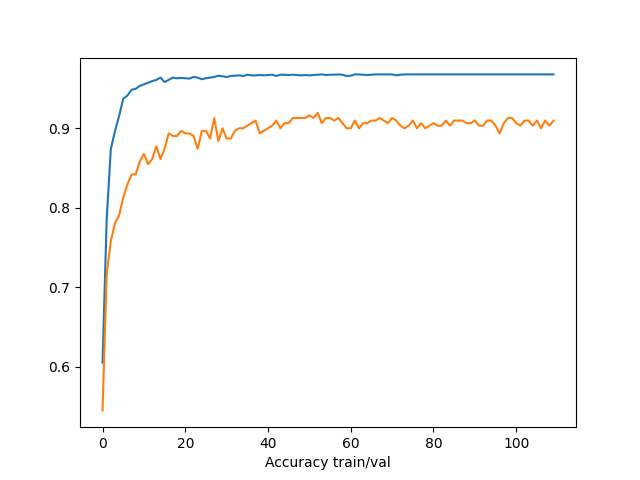

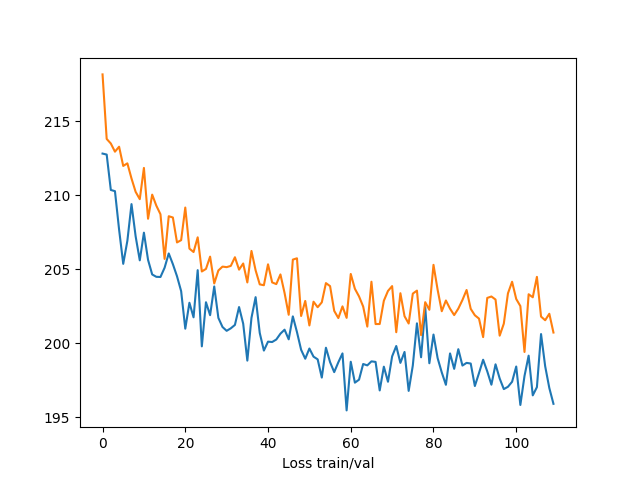

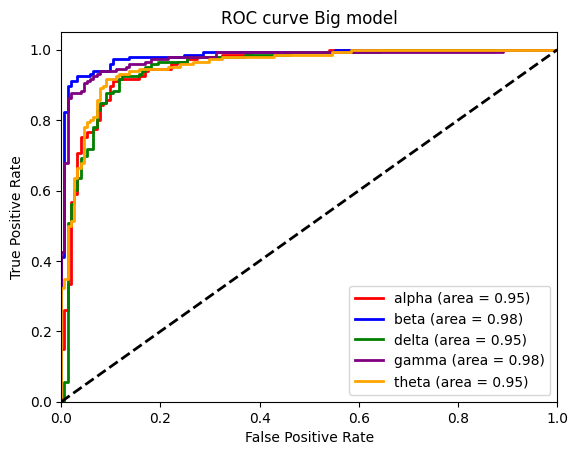

In [20]:
metrics = model.metrics_show()
# metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn = metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
print('Best model')
print(best_mn, '\n')
dir = f"{LOG_DIR}{best_mn.iloc[0]}_{best_mn.iloc[1].replace(' ', '_')}_{best_mn.iloc[2]}_{best_mn.iloc[3]}/"

print('Classification report')
classification_report_file = f'{dir}classification_report.pkl'
with open(classification_report_file, 'rb') as f:
    loaded_report = pickle.load(f)
report_df = pd.DataFrame(loaded_report).transpose()
print(report_df, '\n')

accuracy_file = f'{dir}accuracy.png'
display(IPImage(filename=accuracy_file))

loss_file = f'{dir}loss.png'
display(IPImage(filename=loss_file))



fpr = {}
tpr = {}
roc_auc = {}
i = 0

for rhythm in Config.RHYTHMS:
    
    dir = f"{LOG_DIR}{best_mn.iloc[0]}_{best_mn.iloc[1].replace(' ', '_')}_{rhythm}_{best_mn.iloc[3]}/"
    roc_auc_pred_file = f'{dir}roc_pred.pkl'
    roc_auc_true_file = f'{dir}roc_true_dump.pkl'
    with open(roc_auc_pred_file, 'rb') as f:
        roc_auc_pred = pickle.load(f)
    with open(roc_auc_true_file, 'rb') as f:
        roc_auc_true = pickle.load(f)    
    targets_pred = roc_auc_pred
    targets_true = roc_auc_true
    fpr[i], tpr[i], _ = roc_curve(targets_true, targets_pred)
    roc_auc[i] = roc_auc_score(targets_true, targets_pred)
    i = i+1


# Параметры для построения всех ROC-кривых на одном графике
plt.figure()
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i, color in zip(range(len(roc_auc)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='{0} (area = {1:0.2f})'
                   ''.format(Config.RHYTHMS[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC curve {best_mn.iloc[0]} model')
plt.legend(loc="lower right")
plt.show()

# Shap

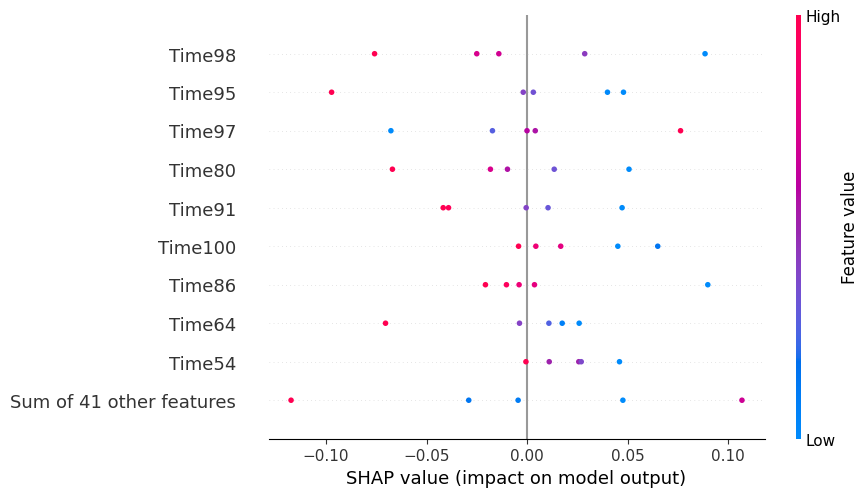

In [21]:
time_samples = 50
max_samples = 5
experiment = best_mn.iloc[1]
signal = best_mn.iloc[2]

ds = CustomDataset(experiment, signal, DATASET, True, max_samples)
# ds = CustomDataset(best_mn.iloc[1], best_mn.iloc[2], DATASET, True, 5)

class ShapModel(nn.Module):
    def __init__(self):
        super(ShapModel, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(time_samples, 1000, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(1000),
            nn.Linear(1000, 10, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Linear(10, 1, bias=False),
            nn.Sigmoid(),
        )    
        
    def forward(self, x):

        x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device('cpu'))
        x = self.linear_stack(x)
        x = x.squeeze()
        return x

model = ShapModel()        


set_seed(Config.seed)

shap.initjs()
X = ds.dataframe
X = X.iloc[:,7:]
# X.drop('__index_level_0__', axis=1, inplace=True)

samples = X.iloc[np.random.choice(np.arange(len(X)), max_samples, replace=False)]
samples=samples.astype(float, errors="ignore")
background = samples.iloc[:, :time_samples]
values = samples.iloc[:, time_samples+1:2*time_samples+1]

# self.__init__('Small', background.shape[1], background.shape[0])
# self.shap_mode = True
e = shap.Explainer(model, background, max_evals=samples.shape[1]*2+1)
shap_values = e(values)
shap.plots.beeswarm(shap_values)

# TEST

In [22]:
df = DATASET['alpha'].to_pandas()

In [23]:
df

,Dataset,channel,Channel_Name,band,frequency,Intencity,participant,Time0,Time1,Time2,...,Time14991,Time14992,Time14993,Time14994,Time14995,Time14996,Time14997,Time14998,Time14999,__index_level_0__
0,Mona Lisa,0,O2-A2,3,alpha,0.1,1,-3.7877484676085507,-18.4037880568239,-31.726911379759112,...,-21.11098576948976,-22.139076996590173,-21.838392961197147,-20.12747732240493,-17.020426535507227,-12.629057427081623,-7.153919067630163,-0.8819641114161927,5.823794977252651,0
1,Mona Lisa,1,O1-A1,3,alpha,0.1,1,-7.968681354835845,-8.840463565797092,-9.143071285582437,...,-24.306133658255284,-21.576791341405556,-17.27470845429491,-11.651353312626226,-5.068360933975659,2.0344586327692324,9.175119081980128,15.854464009792547,21.587947836018422,1
2,Mona Lisa,2,P4-A2,3,alpha,0.1,1,-13.373959023272686,-11.517050415805972,-8.740575990131848,...,-23.959918766346572,-24.07050886219999,-22.541134224679844,-19.479654219201514,-15.10329722413013,-9.722216730846245,-3.717187175826689,2.48814240193232,8.459409395160073,2
3,Mona Lisa,3,P3-A1,3,alpha,0.1,1,-6.756083132735056,-6.946923495303239,-6.669265523565157,...,-38.00202122586408,-36.519980673671185,-32.607470453482264,-26.43414483021141,-18.33143251953191,-8.774428652511975,1.6494019513770515,12.27726666440899,22.41351732110965,3
4,Mona Lisa,4,C4-A2,3,alpha,0.1,1,-3.276661483237142,-8.660899524772816,-13.31567807297543,...,-5.0920186212204985,-3.929964006330922,-2.645906214314347,-1.3585303122483667,-0.17540624288828377,0.8131139575224788,1.5413807435493134,1.9744935836624107,2.1090197820147507,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6195,Necker cube,26,TP7-A1,3,alpha,1,10,9.886516983474728,0.24624248699401274,-9.503668040736613,...,4.422938628487724,0.7141967546867399,-3.483962995423954,-7.860768263171656,-12.06808154339576,-15.74874345324224,-18.571560272075708,-20.25915138367543,-20.608219883123247,18595
6196,Necker cube,27,CP3-A1,3,alpha,1,10,23.893096416729954,18.70127306759578,12.27035711008253,...,12.177479246578404,3.1125465483850743,-6.842133664943575,-17.00947800573732,-26.658934096082817,-35.06338690529244,-41.558149653301,-45.592190931948664,-46.76988111441672,18596
6197,Necker cube,28,Cpz-A1,3,alpha,1,10,21.573248586628534,17.4260421958212,12.294068756288658,...,5.681547729038619,-0.6113939457471163,-7.418314291837252,-14.348056846470005,-20.96177702604588,-26.80449081971192,-31.44224386626471,-34.49245413589476,-35.6492865709718,18597
6198,Necker cube,29,CP4-A2,3,alpha,1,10,19.54787384183338,40.83639560357758,59.62668325840616,...,-0.11977239575034915,-4.188060286777526,-8.435836256724052,-12.676702379292042,-16.688903614137622,-20.234183219583755,-23.078755969137017,-25.003935364169593,-25.819305869914565,18598


In [24]:
df.iloc[:, 1:-1].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
6195    False
6196    False
6197    False
6198    False
6199    False
Length: 6200, dtype: bool

In [25]:
xdf = df.iloc[:, 7:-1]

In [26]:
xdf

,Time0,Time1,Time2,Time3,Time4,Time5,Time6,Time7,Time8,Time9,...,Time14990,Time14991,Time14992,Time14993,Time14994,Time14995,Time14996,Time14997,Time14998,Time14999
0,-3.7877484676085507,-18.4037880568239,-31.726911379759112,-42.86281568319731,-51.07395991196573,-55.84076020537384,-56.88459120096554,-54.182318596078076,-47.97939247437394,-38.770302914525125,...,-18.91265003606081,-21.11098576948976,-22.139076996590173,-21.838392961197147,-20.12747732240493,-17.020426535507227,-12.629057427081623,-7.153919067630163,-0.8819641114161927,5.823794977252651
1,-7.968681354835845,-8.840463565797092,-9.143071285582437,-8.81448620927821,-7.84138667370681,-6.2581814045009025,-4.140184804355963,-1.6044140809496257,1.1887913576556244,4.05030329582804,...,-25.328021373027568,-24.306133658255284,-21.576791341405556,-17.27470845429491,-11.651353312626226,-5.068360933975659,2.0344586327692324,9.175119081980128,15.854464009792547,21.587947836018422
2,-13.373959023272686,-11.517050415805972,-8.740575990131848,-5.139814224658595,-0.8796860108987953,3.8103668213389525,8.650377076581844,13.325153841677322,17.502616209647595,20.856674046385756,...,-22.218528466530856,-23.959918766346572,-24.07050886219999,-22.541134224679844,-19.479654219201514,-15.10329722413013,-9.722216730846245,-3.717187175826689,2.48814240193232,8.459409395160073
3,-6.756083132735056,-6.946923495303239,-6.669265523565157,-5.87230351109155,-4.5455111429639885,-2.722153858647825,-0.4785799436521112,2.0653670534952955,4.750479339904569,7.390358719991207,...,-37.05168777620561,-38.00202122586408,-36.519980673671185,-32.607470453482264,-26.43414483021141,-18.33143251953191,-8.774428652511975,1.6494019513770515,12.27726666440899,22.41351732110965
4,-3.276661483237142,-8.660899524772816,-13.31567807297543,-16.893821419733285,-19.13373074937776,-19.879619402072784,-19.09186865831466,-16.852537429944178,-13.359649278782486,-8.90946080319841,...,-6.013956211747249,-5.0920186212204985,-3.929964006330922,-2.645906214314347,-1.3585303122483667,-0.17540624288828377,0.8131139575224788,1.5413807435493134,1.9744935836624107,2.1090197820147507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6195,9.886516983474728,0.24624248699401274,-9.503668040736613,-18.79073426353945,-27.06490988872599,-33.834923223686324,-38.699100484757295,-41.366712283031106,-41.67653750966435,-39.60895133412397,...,7.38802637831912,4.422938628487724,0.7141967546867399,-3.483962995423954,-7.860768263171656,-12.06808154339576,-15.74874345324224,-18.571560272075708,-20.25915138367543,-20.608219883123247
6196,23.893096416729954,18.70127306759578,12.27035711008253,4.909628933597764,-3.004128523509826,-11.04544102702744,-18.762554999879143,-25.70333802122549,-31.442332907324992,-35.606533105266855,...,19.772373812772752,12.177479246578404,3.1125465483850743,-6.842133664943575,-17.00947800573732,-26.658934096082817,-35.06338690529244,-41.558149653301,-45.592190931948664,-46.76988111441672
6197,21.573248586628534,17.4260421958212,12.294068756288658,6.39516513316325,-0.008026016139205616,-6.619258941456299,-13.120849114412694,-19.186651185753284,-24.498790456594378,-28.763708353391614,...,11.134324891202937,5.681547729038619,-0.6113939457471163,-7.418314291837252,-14.348056846470005,-20.96177702604588,-26.80449081971192,-31.44224386626471,-34.49245413589476,-35.6492865709718
6198,19.54787384183338,40.83639560357758,59.62668325840616,74.6517049729343,84.89448589650918,89.6604145214619,88.62696670309515,81.86666282937065,69.84251585521875,53.37535167709815,...,3.6156220017740477,-0.11977239575034915,-4.188060286777526,-8.435836256724052,-12.676702379292042,-16.688903614137622,-20.234183219583755,-23.078755969137017,-25.003935364169593,-25.819305869914565


In [27]:
xdf.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
6195    False
6196    False
6197    False
6198    False
6199    False
Length: 6200, dtype: bool

In [28]:
xdf.dtypes

Time0        object
Time1        object
Time2        object
Time3        object
Time4        object
              ...  
Time14995    object
Time14996    object
Time14997    object
Time14998    object
Time14999    object
Length: 15000, dtype: object

In [29]:
xdf=xdf.apply(pd.to_numeric)



In [30]:
xdf.dtypes

Time0        float64
Time1        float64
Time2        float64
Time3        float64
Time4        float64
              ...   
Time14995    float64
Time14996    float64
Time14997    float64
Time14998    float64
Time14999    float64
Length: 15000, dtype: object

In [31]:
import pandas as pd
import numpy as np

# Создаем пример большого DataFrame (6200 строк и 15000 столбцов)
# df = pd.DataFrame(np.random.rand(6200, 15000))

# Функция для усреднения каждых n столбцов
def average_columns(df, n):
    # Определяем количество новых столбцов
    num_new_columns = df.shape[1] // n
    
    # Создаем новый DataFrame для хранения результатов
    averaged_df = pd.DataFrame(index=df.index)
    
    for i in range(num_new_columns):
        start_col = i * n
        end_col = start_col + n

        #print(f"avg_{start_col}_{end_col}")
        #print(df.iloc[:, start_col:end_col].mean(axis=1))
        #break

        
        #averaged_df[f"avg_{start_col}_{end_col}"] = df.iloc[:, start_col:end_col].mean(axis=1)
        averaged_df[f"avg_{start_col//n}"] = df.iloc[:, start_col:end_col].mean(axis=1)
    
    
    return averaged_df

# Применяем функцию для усреднения каждых 250 столбцов
new_df = average_columns(xdf, 250)

# Проверяем результат
print(new_df.head())
print(new_df.shape)


      avg_0     avg_1     avg_2     avg_3     avg_4     avg_5     avg_6  \
0 -0.514894 -0.065711 -0.524931  0.748074 -0.211523  0.457606  0.686477   
1 -0.188954  0.172599 -0.188831  0.373858 -0.354219  0.593052 -0.535925   
2  0.101869  0.276241 -1.192060  0.844493 -0.455134  0.227780  1.025581   
3 -0.605900  0.936441 -0.895484  0.073974 -0.212891  1.428886 -0.744888   
4 -0.671473  0.858988 -0.663521  0.162659 -0.586728  0.857905  0.405098   

      avg_7     avg_8     avg_9  ...    avg_50    avg_51    avg_52    avg_53  \
0  0.012952 -0.635043  0.399724  ...  0.417247  0.054687  0.355678 -0.495348   
1  0.280749 -0.369283  0.524406  ...  0.057672 -0.075861  0.198058 -0.304818   
2 -1.039043 -0.624893  0.324914  ...  0.002515  0.235172 -0.070223 -0.752749   
3  0.211320 -0.727818  0.811403  ... -0.228186  0.196476 -0.561060 -0.321475   
4 -0.458742 -0.183167  0.687727  ... -0.390291  0.017120 -0.144456  0.231585   

     avg_54    avg_55    avg_56    avg_57    avg_58    avg_59  
0 -0

In [32]:
new_df

,avg_0,avg_1,avg_2,avg_3,avg_4,avg_5,avg_6,avg_7,avg_8,avg_9,...,avg_50,avg_51,avg_52,avg_53,avg_54,avg_55,avg_56,avg_57,avg_58,avg_59
0,-0.514894,-0.065711,-0.524931,0.748074,-0.211523,0.457606,0.686477,0.012952,-0.635043,0.399724,...,0.417247,0.054687,0.355678,-0.495348,-0.295532,0.535284,-0.378295,-0.214454,0.526914,-1.058016
1,-0.188954,0.172599,-0.188831,0.373858,-0.354219,0.593052,-0.535925,0.280749,-0.369283,0.524406,...,0.057672,-0.075861,0.198058,-0.304818,-0.182138,0.412377,-0.089291,0.237674,-0.255267,-0.180074
2,0.101869,0.276241,-1.192060,0.844493,-0.455134,0.227780,1.025581,-1.039043,-0.624893,0.324914,...,0.002515,0.235172,-0.070223,-0.752749,-0.232216,0.609821,-0.363513,0.169010,0.444370,-0.993670
3,-0.605900,0.936441,-0.895484,0.073974,-0.212891,1.428886,-0.744888,0.211320,-0.727818,0.811403,...,-0.228186,0.196476,-0.561060,-0.321475,-0.210228,0.708783,-0.373873,0.188838,-0.004200,-0.938804
4,-0.671473,0.858988,-0.663521,0.162659,-0.586728,0.857905,0.405098,-0.458742,-0.183167,0.687727,...,-0.390291,0.017120,-0.144456,0.231585,-0.622188,0.251827,-0.166629,-0.080353,0.556502,-0.634657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6195,-0.479329,0.304368,0.147442,-0.502862,0.122162,0.248051,0.233025,-0.074133,0.282975,0.079958,...,-0.151034,0.126276,0.372477,-0.207059,0.561715,-0.081829,0.228380,-0.014883,0.440301,-0.115710
6196,-0.298050,0.275581,0.363743,-0.687371,-0.000014,0.453857,0.264467,-0.182020,-0.019294,-0.019422,...,-0.266304,-0.251950,0.463276,-0.321013,0.510897,0.105630,-0.410070,-0.052678,0.716997,-0.351405
6197,-0.479955,0.207849,0.831763,-0.748941,0.113344,0.652025,0.150922,-0.059205,-0.045319,0.323765,...,0.080479,-0.537335,0.425184,0.107582,-0.200581,0.623501,-0.471228,-0.395153,1.270734,-0.247261
6198,1.169039,-0.105474,0.388235,-0.695087,-0.010326,0.249931,-0.703487,0.284633,-0.142079,0.251619,...,-0.230337,-0.613727,-0.065247,-0.153395,-0.120546,-0.020966,-0.641934,-0.731375,0.804015,-0.378590


PermutationExplainer explainer: 6201it [07:48, 12.93it/s]                       


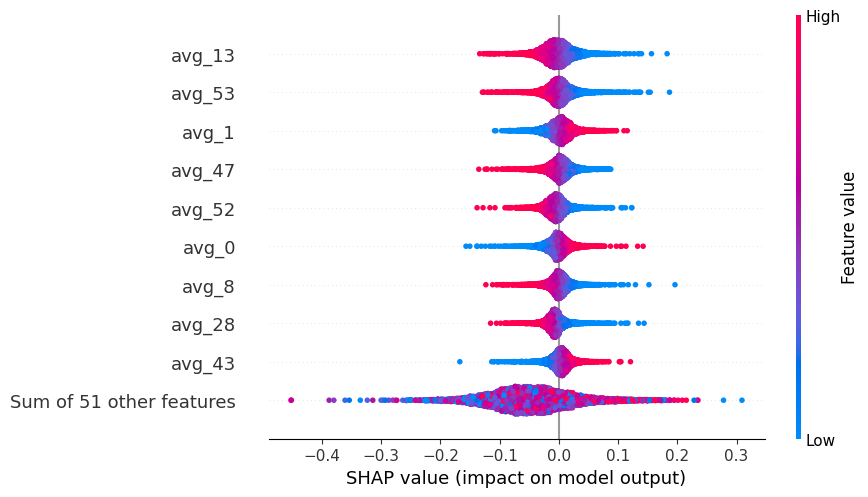

In [33]:
time_samples = 60
max_samples = 6200
# experiment = best_mn.iloc[1]
# signal = best_mn.iloc[2]

# ds = CustomDataset(experiment, signal, DATASET, True, max_samples)
# ds = CustomDataset(best_mn.iloc[1], best_mn.iloc[2], DATASET, True, 5)

class ShapModel(nn.Module):
    def __init__(self):
        super(ShapModel, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(time_samples, 1000, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(1000),
            nn.Linear(1000, 10, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Linear(10, 1, bias=False),
            nn.Sigmoid(),
        )    
        
    def forward(self, x):

        x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device('cpu'))
        x = self.linear_stack(x)
        x = x.squeeze()
        return x

model = ShapModel()        


set_seed(Config.seed)

shap.initjs()
# X = ds.dataframe
# X = X.iloc[:,7:]
# X.drop('__index_level_0__', axis=1, inplace=True)
X = new_df

samples = X.iloc[np.random.choice(np.arange(len(X)), max_samples, replace=False)]
background = samples.iloc[:, :time_samples]
#values = samples.iloc[:, time_samples+1:2*time_samples+1]
values = samples.iloc[:, :time_samples]


# self.__init__('Small', background.shape[1], background.shape[0])
# self.shap_mode = True
e = shap.Explainer(model, background)
shap_values = e(values)
shap.plots.beeswarm(shap_values)

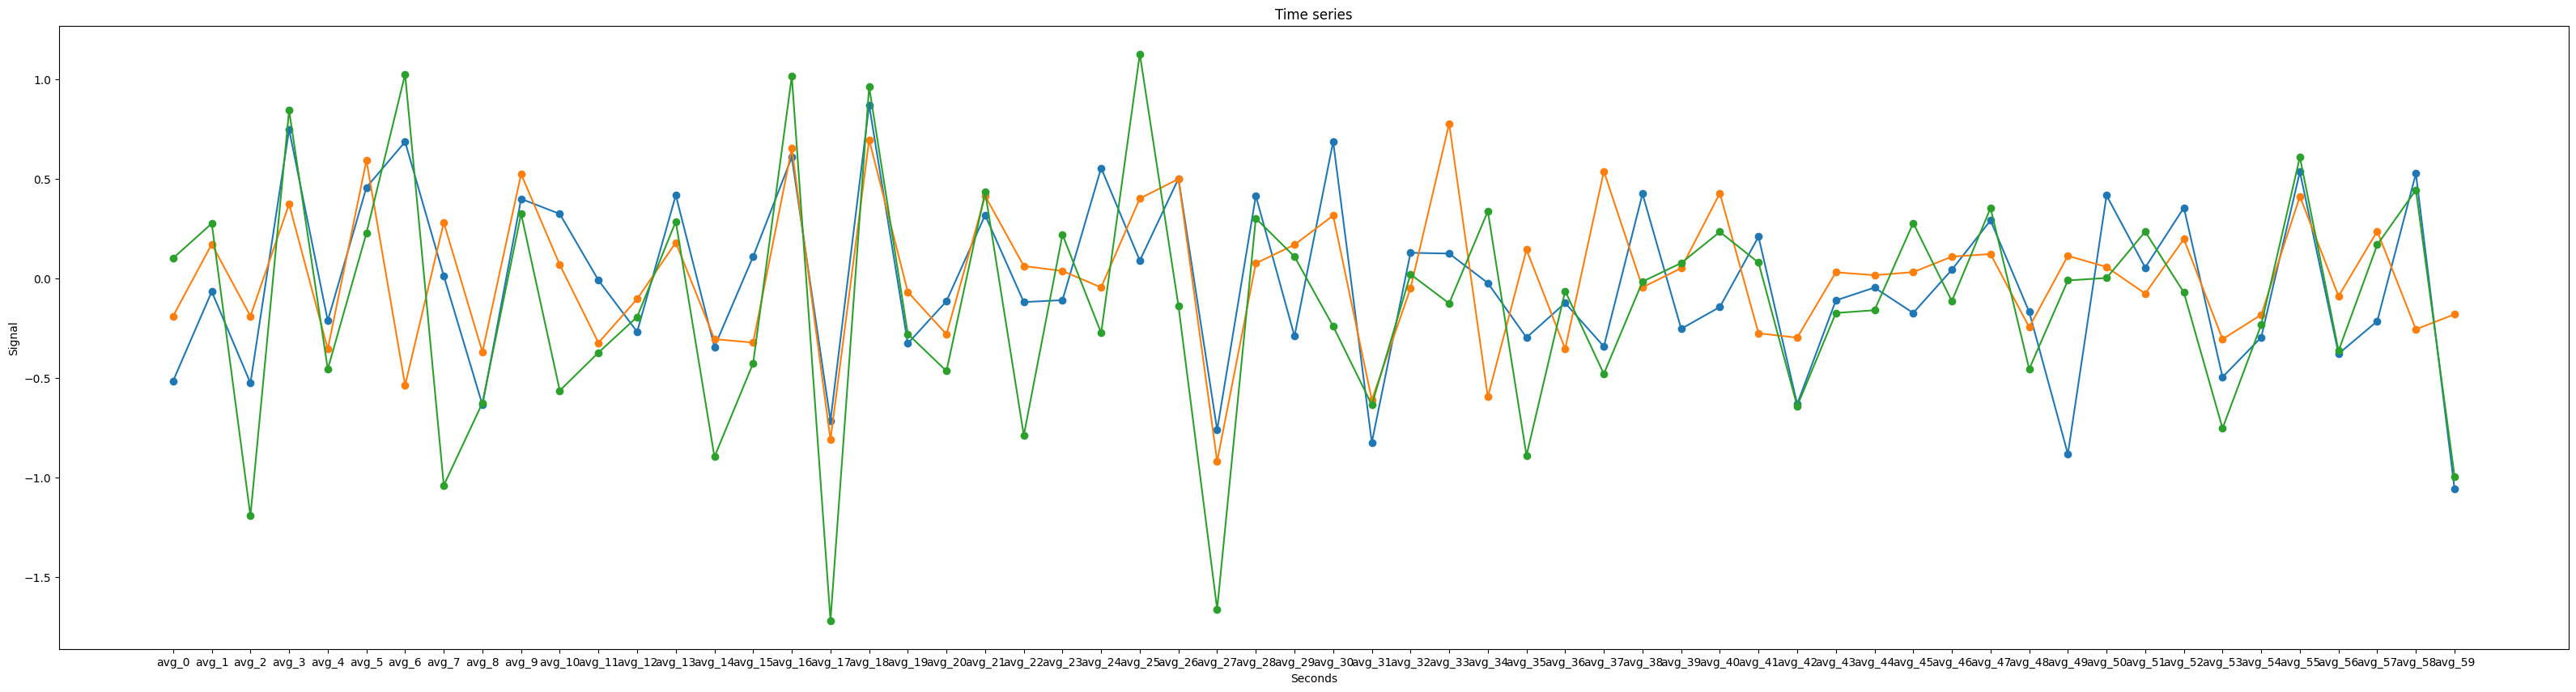

In [34]:

plt.figure(figsize=(40,10))

plt.plot(X.iloc[0,:],"o-")
plt.plot(X.iloc[1,:],"o-")
plt.plot(X.iloc[2,:],"o-")
plt.title('Time series')
plt.xlabel("Seconds")
plt.ylabel("Signal")
plt.show()


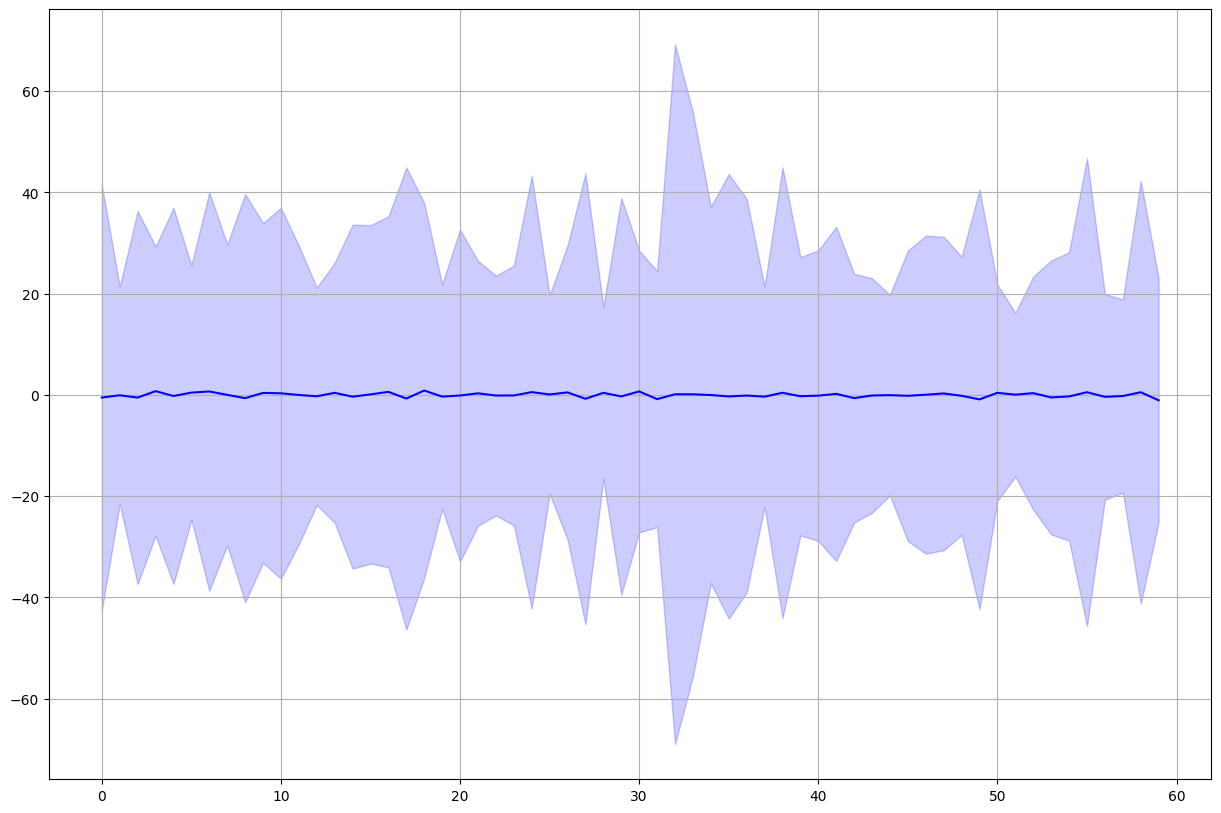

In [38]:

ma = xdf.iloc[0].rolling(250,min_periods=250).mean()

mstd = xdf.iloc[0].rolling(250,min_periods=250).std()

ma60=[ma.values[i] for i in range(249,15000,250)]
mstd60=[mstd.values[i] for i in range(249,15000,250)]

ma60=pd.Series(ma60)
mstd60=pd.Series(mstd60)

plt.figure(figsize=(15,10));
plt.grid()

#plt.plot(range(len(xdf.iloc[0])), xdf.iloc[0], "k"plt.figure();

#plt.plot(range(len(xdf.iloc[0])), xdf.iloc[0], "k", "o");



plt.plot(range(len(ma60)), ma60, "b");

plt.fill_between(range(len(mstd60)), ma60 - 2 * mstd60, ma60 + 2 * mstd60, color="b", alpha=0.2);

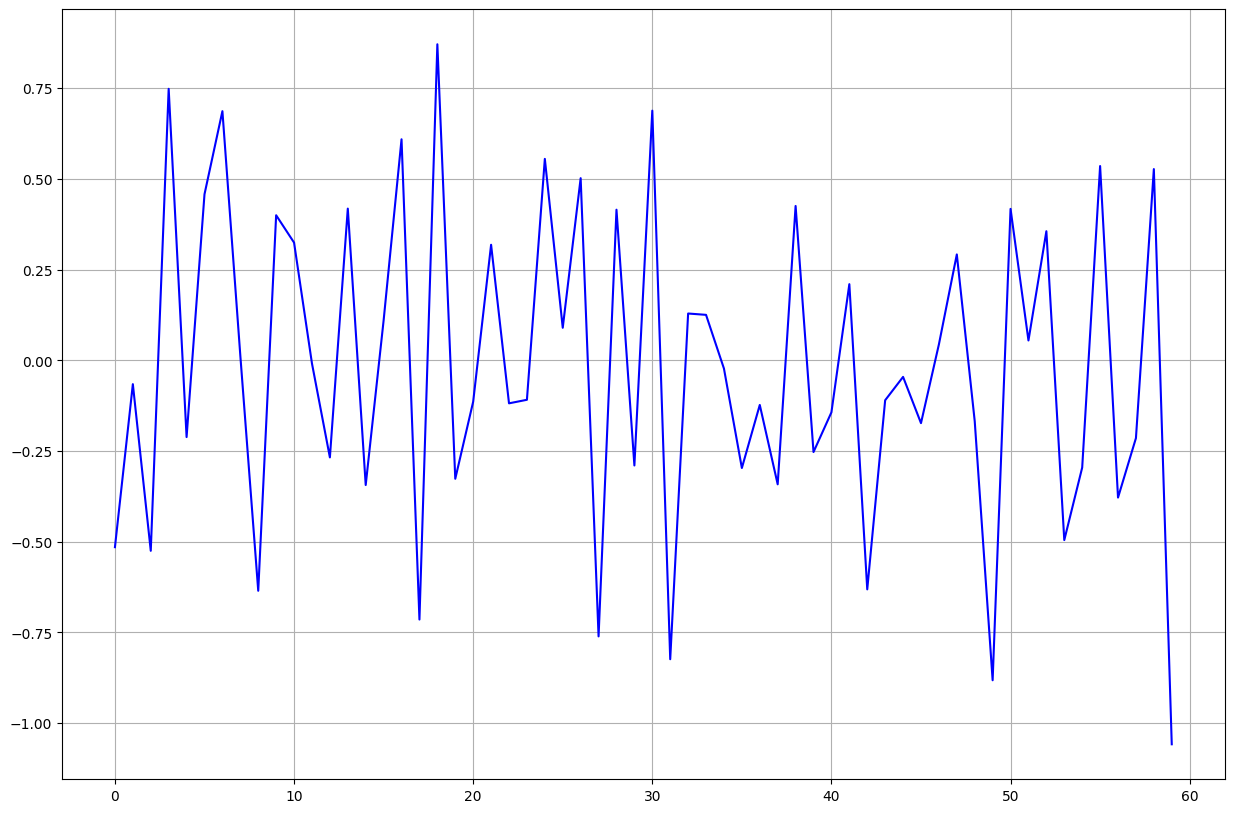

In [39]:
plt.figure(figsize=(15,10));

plt.grid()

plt.plot(range(len(ma60)), ma60, "b");



In [40]:
ma60.values

array([-0.51489366, -0.06571126, -0.52493059,  0.7480741 , -0.21152331,
        0.45760565,  0.68647662,  0.01295248, -0.63504304,  0.39972379,
        0.32433695, -0.00882244, -0.26751711,  0.41797853, -0.34366208,
        0.10997329,  0.60901734, -0.71428602,  0.87080395, -0.32640033,
       -0.11397979,  0.31837109, -0.11854838, -0.1087791 ,  0.5550232 ,
        0.089665  ,  0.50186959, -0.76075543,  0.41499175, -0.28979897,
        0.68791466, -0.82366768,  0.12894635,  0.12525219, -0.02275934,
       -0.29675698, -0.12300731, -0.34168708,  0.42527568, -0.25279112,
       -0.14329231,  0.20980932, -0.63115758, -0.11005235, -0.04570457,
       -0.17312583,  0.04383089,  0.29171818, -0.16771614, -0.88162885,
        0.41724659,  0.05468746,  0.35567841, -0.49534759, -0.29553182,
        0.53528366, -0.37829488, -0.21445378,  0.52691397, -1.05801594])

In [41]:
mstd60.values

array([21.01567301, 10.73820197, 18.42804802, 14.28375638, 18.5708433 ,
       12.56734942, 19.69399344, 14.85795674, 20.17199627, 16.77225391,
       18.31570236, 14.74821316, 10.7415659 , 12.84209563, 16.98892284,
       16.71547907, 17.33119562, 22.82009052, 18.52706263, 11.08341751,
       16.39599631, 13.08469047, 11.84724823, 12.81330542, 21.37862083,
        9.81522689, 14.52292389, 22.27536181,  8.49476264, 19.59548765,
       13.91926019, 12.65814029, 34.56931135, 27.86138538, 18.59780905,
       21.95873012, 19.43854142, 10.87972953, 22.26355674, 13.74318122,
       14.35261793, 16.51281385, 12.29150123, 11.57407838,  9.91385224,
       14.34507806, 15.70760876, 15.48191598, 13.73981539, 20.72709997,
       10.67518131,  8.09265183, 11.51961292, 13.5254562 , 14.24613819,
       23.11438005, 10.1566559 ,  9.54883745, 20.88614999, 12.06230691])

In [42]:
ma60 - 2 * mstd60

0    -42.546240
1    -21.542115
2    -37.381027
3    -27.819439
4    -37.353210
5    -24.677093
6    -38.701510
7    -29.702961
8    -40.979036
9    -33.144784
10   -36.307068
11   -29.505249
12   -21.750649
13   -25.266213
14   -34.321508
15   -33.320985
16   -34.053374
17   -46.354467
18   -36.183321
19   -22.493235
20   -32.905972
21   -25.851010
22   -23.813045
23   -25.735390
24   -42.202218
25   -19.540789
26   -28.543978
27   -45.311479
28   -16.574534
29   -39.480774
30   -27.150606
31   -26.139948
32   -69.009676
33   -55.597519
34   -37.218377
35   -44.214217
36   -39.000090
37   -22.101146
38   -44.101838
39   -27.739154
40   -28.848528
41   -32.815818
42   -25.214160
43   -23.258209
44   -19.873409
45   -28.863282
46   -31.371387
47   -30.672114
48   -27.647347
49   -42.335829
50   -20.933116
51   -16.130616
52   -22.683547
53   -27.546260
54   -28.787808
55   -45.693476
56   -20.691607
57   -19.312129
58   -41.245386
59   -25.182630
dtype: float64

# TEST 2

Model                 Small
Dataset           Mona Lisa
Rhythm                 beta
Optimizer              Adam
Start LR            0.00001
Final LR            0.00001
Epoch                    47
Train Accuracy     0.953226
Val Accuracy       0.903226
Test Accuracy      0.916129
Train Time           102.83
Inference Time         0.96
ROC AUC            0.982476

In [60]:
model = RobiulModel(model_name="Small", experiment="Mona Lisa", rhythm="beta", optimizer="Adam", batch_size=100)
model.fit()
model.test()

Epoch: [1/200] | train_loss = [213.8571] : train_acc = [0.6903] : val_loss = [212.8970] : val_acc = [0.7968] : lr = [1e-05]


Epoch: [2/200] | train_loss = [209.7922] : train_acc = [0.9367] : val_loss = [212.5086] : val_acc = [0.8677] : lr = [1e-05]
Find best loss=[212.89700908045614], model saved on 2 epoch


Epoch: [3/200] | train_loss = [206.9685] : train_acc = [0.9532] : val_loss = [211.6191] : val_acc = [0.8871] : lr = [1e-05]
Find best loss=[212.5086187547253], model saved on 3 epoch


Epoch: [4/200] | train_loss = [206.4611] : train_acc = [0.9617] : val_loss = [211.1776] : val_acc = [0.9000] : lr = [1e-05]
Find best loss=[211.61908057428175], model saved on 4 epoch


Epoch: [5/200] | train_loss = [206.3529] : train_acc = [0.9601] : val_loss = [210.9777] : val_acc = [0.9032] : lr = [1e-05]
Find best loss=[211.1775650516633], model saved on 5 epoch


Epoch: [6/200] | train_loss = [205.9239] : train_acc = [0.9625] : val_loss = [210.3173] : val_acc = [0.9000] : lr = [1e-05]
Find best loss=[210.9776847593246], model saved on 6 epoch


Epoch: [7/200] | train_loss = [205.5340] : train_acc = [0.9641] : val_loss = [210.7398] : val_acc = [0.8968] : lr = [1e-05]


Epoch: [8/200] | train_loss = [206.7595] : train_acc = [0.9617] : val_loss = [210.3749] : val_acc = [0.9065] : lr = [1e-05]


Epoch: [9/200] | train_loss = [206.3686] : train_acc = [0.9609] : val_loss = [210.4730] : val_acc = [0.9032] : lr = [1e-05]


Epoch: [10/200] | train_loss = [205.1781] : train_acc = [0.9617] : val_loss = [209.8722] : val_acc = [0.9226] : lr = [1e-05]
Find best loss=[210.31725483555948], model saved on 10 epoch


Epoch: [11/200] | train_loss = [206.0218] : train_acc = [0.9605] : val_loss = [210.0484] : val_acc = [0.9000] : lr = [1e-05]


Epoch: [12/200] | train_loss = [204.8750] : train_acc = [0.9601] : val_loss = [210.3625] : val_acc = [0.9000] : lr = [1e-05]


Epoch: [13/200] | train_loss = [205.5278] : train_acc = [0.9609] : val_loss = [209.9859] : val_acc = [0.9000] : lr = [1e-05]


Epoch: [14/200] | train_loss = [205.2108] : train_acc = [0.9597] : val_loss = [209.8225] : val_acc = [0.8968] : lr = [1e-05]
Find best loss=[209.8721904139365], model saved on 14 epoch


Epoch: [15/200] | train_loss = [205.4378] : train_acc = [0.9581] : val_loss = [209.6435] : val_acc = [0.9032] : lr = [1e-05]
Find best loss=[209.8224861391129], model saved on 15 epoch


Epoch: [16/200] | train_loss = [205.3196] : train_acc = [0.9577] : val_loss = [209.8533] : val_acc = [0.9065] : lr = [1e-05]


Epoch: [17/200] | train_loss = [206.2860] : train_acc = [0.9573] : val_loss = [210.0232] : val_acc = [0.9065] : lr = [1e-05]


Epoch: [18/200] | train_loss = [204.8976] : train_acc = [0.9556] : val_loss = [209.6582] : val_acc = [0.9032] : lr = [1e-05]


Epoch: [19/200] | train_loss = [204.9917] : train_acc = [0.9573] : val_loss = [209.6137] : val_acc = [0.9000] : lr = [1e-05]
Find best loss=[209.64346608807963], model saved on 19 epoch


Epoch: [20/200] | train_loss = [204.3669] : train_acc = [0.9597] : val_loss = [209.5566] : val_acc = [0.9032] : lr = [1e-05]
Find best loss=[209.61369176064767], model saved on 20 epoch


Epoch: [21/200] | train_loss = [203.9964] : train_acc = [0.9581] : val_loss = [209.6941] : val_acc = [0.9065] : lr = [1e-05]


Epoch: [22/200] | train_loss = [205.8041] : train_acc = [0.9573] : val_loss = [209.7591] : val_acc = [0.8968] : lr = [1e-05]


Epoch: [23/200] | train_loss = [205.3210] : train_acc = [0.9552] : val_loss = [209.4989] : val_acc = [0.9065] : lr = [1e-05]
Find best loss=[209.55658451203377], model saved on 23 epoch


Epoch: [24/200] | train_loss = [206.0264] : train_acc = [0.9589] : val_loss = [209.3290] : val_acc = [0.9000] : lr = [1e-05]
Find best loss=[209.4989013671875], model saved on 24 epoch


Epoch: [25/200] | train_loss = [203.7169] : train_acc = [0.9565] : val_loss = [209.4572] : val_acc = [0.9000] : lr = [1e-05]


Epoch: [26/200] | train_loss = [205.0109] : train_acc = [0.9565] : val_loss = [209.4272] : val_acc = [0.9032] : lr = [1e-05]


Epoch: [27/200] | train_loss = [204.7435] : train_acc = [0.9585] : val_loss = [209.3043] : val_acc = [0.9032] : lr = [1e-05]
Find best loss=[209.32903658959174], model saved on 27 epoch


Epoch: [28/200] | train_loss = [205.9908] : train_acc = [0.9565] : val_loss = [209.4527] : val_acc = [0.9032] : lr = [1e-05]


Epoch: [29/200] | train_loss = [205.2738] : train_acc = [0.9577] : val_loss = [209.6591] : val_acc = [0.9097] : lr = [1e-05]


Epoch: [30/200] | train_loss = [205.6053] : train_acc = [0.9565] : val_loss = [209.2766] : val_acc = [0.9065] : lr = [1e-05]
Find best loss=[209.30425828503024], model saved on 30 epoch


Epoch: [31/200] | train_loss = [203.8643] : train_acc = [0.9581] : val_loss = [209.2375] : val_acc = [0.9065] : lr = [1e-05]
Find best loss=[209.27660542149698], model saved on 31 epoch


Epoch: [32/200] | train_loss = [205.3335] : train_acc = [0.9573] : val_loss = [209.3113] : val_acc = [0.9032] : lr = [1e-05]


Epoch: [33/200] | train_loss = [203.6148] : train_acc = [0.9569] : val_loss = [209.3629] : val_acc = [0.9097] : lr = [1e-05]


Epoch: [34/200] | train_loss = [204.7805] : train_acc = [0.9573] : val_loss = [209.2311] : val_acc = [0.9097] : lr = [1e-05]
Find best loss=[209.2375232327369], model saved on 34 epoch


Epoch: [35/200] | train_loss = [203.7482] : train_acc = [0.9585] : val_loss = [209.3417] : val_acc = [0.9097] : lr = [1e-05]


Epoch: [36/200] | train_loss = [204.4685] : train_acc = [0.9573] : val_loss = [209.2635] : val_acc = [0.9129] : lr = [1e-05]


Epoch: [37/200] | train_loss = [204.8676] : train_acc = [0.9569] : val_loss = [209.2939] : val_acc = [0.9097] : lr = [1.0000000000000002e-06]


Epoch: [38/200] | train_loss = [205.1464] : train_acc = [0.9585] : val_loss = [209.1298] : val_acc = [0.9000] : lr = [1.0000000000000002e-06]
Find best loss=[209.2311046969506], model saved on 38 epoch


Epoch: [39/200] | train_loss = [205.0008] : train_acc = [0.9577] : val_loss = [209.1711] : val_acc = [0.8968] : lr = [1.0000000000000002e-06]


Epoch: [40/200] | train_loss = [203.4549] : train_acc = [0.9585] : val_loss = [209.3231] : val_acc = [0.9065] : lr = [1.0000000000000002e-06]


Epoch: [41/200] | train_loss = [205.7063] : train_acc = [0.9565] : val_loss = [209.0709] : val_acc = [0.9000] : lr = [1.0000000000000002e-06]
Find best loss=[209.1297568044355], model saved on 41 epoch


Epoch: [42/200] | train_loss = [204.2181] : train_acc = [0.9589] : val_loss = [209.1383] : val_acc = [0.9129] : lr = [1.0000000000000002e-06]


Epoch: [43/200] | train_loss = [203.6512] : train_acc = [0.9589] : val_loss = [209.2511] : val_acc = [0.9129] : lr = [1.0000000000000002e-06]


Epoch: [44/200] | train_loss = [205.4858] : train_acc = [0.9585] : val_loss = [209.1795] : val_acc = [0.9000] : lr = [1.0000000000000002e-06]


Epoch: [45/200] | train_loss = [205.4699] : train_acc = [0.9581] : val_loss = [209.1869] : val_acc = [0.9032] : lr = [1.0000000000000002e-06]


Epoch: [46/200] | train_loss = [204.5520] : train_acc = [0.9581] : val_loss = [209.2235] : val_acc = [0.9097] : lr = [1.0000000000000002e-06]


Epoch: [47/200] | train_loss = [205.2773] : train_acc = [0.9581] : val_loss = [209.1221] : val_acc = [0.9097] : lr = [1.0000000000000002e-07]


Epoch: [48/200] | train_loss = [205.2829] : train_acc = [0.9581] : val_loss = [209.1722] : val_acc = [0.9097] : lr = [1.0000000000000002e-07]


Epoch: [49/200] | train_loss = [204.1878] : train_acc = [0.9589] : val_loss = [209.4664] : val_acc = [0.9065] : lr = [1.0000000000000002e-07]


Epoch: [50/200] | train_loss = [204.8816] : train_acc = [0.9585] : val_loss = [209.2625] : val_acc = [0.9097] : lr = [1.0000000000000002e-07]


Epoch: [51/200] | train_loss = [204.3801] : train_acc = [0.9585] : val_loss = [209.1708] : val_acc = [0.9097] : lr = [1.0000000000000002e-07]
 Finished on 51 epoch. 
test_loss: [215.9552] : test_acc: [0.9194]


In [59]:
df = model.test(False)   
df

test_loss: [215.9552] : test_acc: [0.9194]


ValueError: Found input variables with inconsistent numbers of samples: [310, 900]

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6200 entries, 0 to 6199
Columns: 15008 entries, Dataset to __index_level_0__
dtypes: int64(1), object(15007)
memory usage: 709.9+ MB


In [47]:
df.dtypes

Dataset              object
channel              object
Channel_Name         object
band                 object
frequency            object
                      ...  
Time14996            object
Time14997            object
Time14998            object
Time14999            object
__index_level_0__     int64
Length: 15008, dtype: object

In [ ]:
df=df.apply(pd.to_numeric, errors='ignore')


In [ ]:
model.train

In [1]:
df

NameError: name 'df' is not defined

# TEST 3

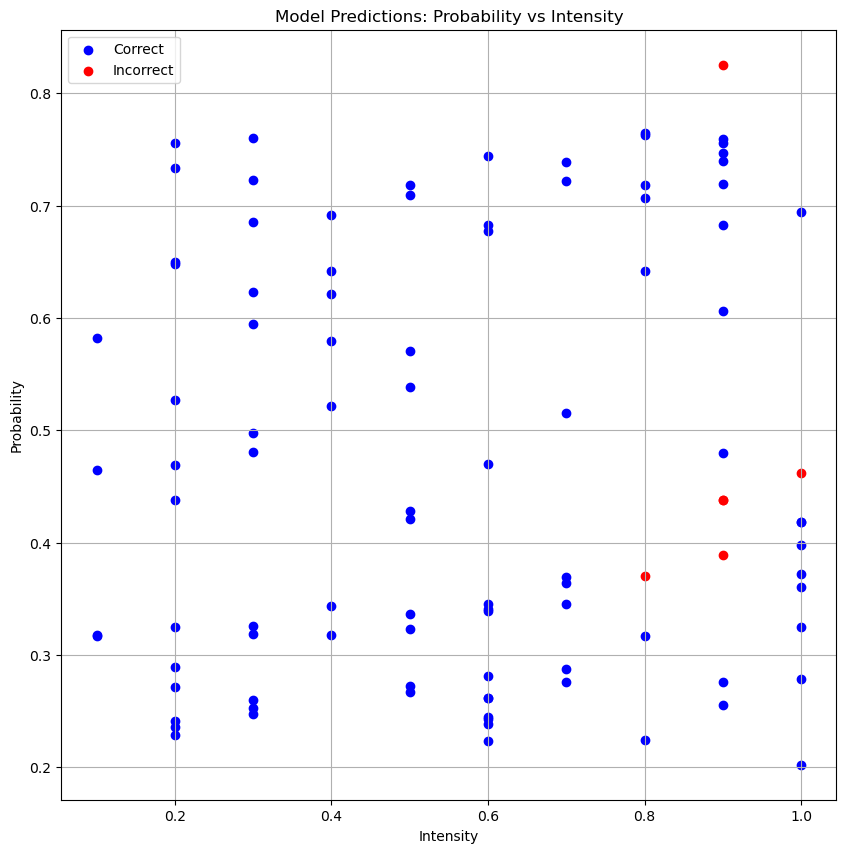

In [30]:
import matplotlib.pyplot as plt
import numpy as np

probabilities = df['Pred']
intensities = df['Intencity']

true_labels =  df['Channel_Name'].map(lambda x: np.int8(0) if 'A1' in x else np.int8(1))
predicted_labels = (probabilities > 0.5).astype(int)

correct_predictions = true_labels == predicted_labels
incorrect_predictions = true_labels != predicted_labels

plt.figure(figsize=(10, 10))
plt.grid()

plt.scatter(intensities[correct_predictions], probabilities[correct_predictions], color='blue', label='Correct')
plt.scatter(intensities[incorrect_predictions], probabilities[incorrect_predictions], color='red', label='Incorrect')

plt.xlabel('Intensity')
plt.ylabel('Probability')
plt.title('Model Predictions: Probability vs Intensity')
plt.legend()
plt.show()


In [23]:
intensities[incorrect_predictions], probabilities[incorrect_predictions]

(0     0.8
 46    0.9
 55    0.9
 67    0.9
 73      1
 95    0.9
 Name: Intencity, dtype: object,
 0     0.370325
 46    0.825345
 55    0.438221
 67    0.389339
 73    0.461509
 95    0.438221
 Name: Pred, dtype: float32)

In [20]:
sum(correct_predictions), sum(incorrect_predictions)

(94, 6)

In [21]:
probabilities.describe()

count    100.000000
mean       0.470801
std        0.186715
min        0.202247
25%        0.316652
50%        0.433224
75%        0.656616
max        0.825345
Name: Pred, dtype: float64

In [22]:
df

,IDX,Pred,Dataset,channel,Channel_Name,band,frequency,Intencity,participant,Time0,...,Time14991,Time14992,Time14993,Time14994,Time14995,Time14996,Time14997,Time14998,Time14999,Stratify
0,2713,0.370325,Mona Lisa,16,Oz-A2,4,beta,0.8,9,24.7920324634759,...,3.5400361806996017,3.8300011297422145,1.600945288576142,-2.1766419476189185,-5.867204301267591,-7.709405542033778,-6.476513745811914,-2.0312620519991498,4.471759616584151,Oz-A2_0.8
1,2555,0.497576,Mona Lisa,13,T3-A1,4,beta,0.3,9,-3.94372117287737,...,-25.50668846147655,-26.353262410530505,-18.3007655533125,-4.0947270349157066,11.018591234553739,21.176706867749708,22.21846826330384,13.508383424754335,-1.5488931103779748,T3-A1_0.3
2,709,0.252425,Mona Lisa,27,CP3-A1,4,beta,0.3,3,3.5914246137609664,...,6.038785748504786,-7.914208710337931,-20.65708378026259,-28.3741904084508,-28.39562966730221,-20.445175223901956,-7.069931272147436,7.094470661412565,17.046504618458165,CP3-A1_0.3
3,2140,0.325021,Mona Lisa,1,O1-A1,4,beta,1,7,-17.719867484980366,...,-37.13424503451291,-30.080404784068094,-11.459291040998753,11.231779720018736,29.008397477016842,35.20235457918332,28.150009531854725,11.64819031374288,-6.935842110039074,O1-A1_1
4,1302,0.722456,Mona Lisa,0,O2-A2,4,beta,0.3,5,-29.936905280977818,...,-35.85294354907037,5.819414085980014,44.16125261476941,64.47913786334584,59.76609125666751,33.64410493510039,-1.4057735948168393,-29.73087663274126,-39.54466470113122,O2-A2_0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2736,0.438221,Mona Lisa,8,Fp2-A2,4,beta,0.9,9,-11.784121908562236,...,15.763869843556137,-102.32819003742891,-185.00999043899037,-197.8667818022873,-134.80457981044952,-21.705395183242885,93.96225837433515,163.29669460756955,157.1317103025176,Fp2-A2_0.9
96,955,0.582410,Mona Lisa,25,FT8-A2,4,beta,0.1,4,-6.343274091128789,...,-28.419773969238005,-37.51676862751077,-40.167295194000005,-33.35987986047451,-16.50955503646793,7.471727506033242,32.47143842155165,50.94457446103896,56.57375674404497,FT8-A2_0.1
97,1004,0.759676,Mona Lisa,12,T4-A2,4,beta,0.3,4,17.203724537721225,...,-22.446473478077323,-10.12189556430234,2.6919182715724554,14.396148536335595,23.879472846726998,30.448218337446598,33.668742104023394,33.246064140285995,29.02908403510703,T4-A2_0.3
98,1902,0.469109,Mona Lisa,11,T5-A1,4,beta,0.2,7,4.424288518188822,...,-21.50858907566689,-9.942060581697026,6.449367218890696,20.855586483957232,27.42836083786804,23.821165407554602,12.068104585174783,-2.5028179637262946,-13.742480271283654,T5-A1_0.2
